In [1]:
pip install pyeit numpy scipy matplotlib pandas scikit-learn opencv-python -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2
import os

import pyeit.mesh as mesh
import pyeit.eit.protocol as protocol
import pyeit.eit.jac as jac

from pyeit.eit.fem import EITForward
from pyeit.mesh.wrapper import PyEITAnomaly_Circle

In [3]:
# -----------------------------
# Basic EIT configuration
# -----------------------------

n_el = 16          # number of electrodes
h0 = 0.03      # mesh size; smaller value = finer mesh
# background_perm = 1.0
# edema_perm = 1.5   # edema conductivity; higher than background

# Current injection and voltage measurement protocol
protocol_obj = protocol.create(
    n_el=n_el,
    dist_exc=1,        # adjacent current injection
    step_meas=1,       # adjacent voltage measurement
    parser_meas="std"
)

print("Protocol created successfully")

Protocol created successfully


In [4]:
# -----------------------------
# Create 2D circular FEM mesh
# -----------------------------

mesh_obj = mesh.create(n_el=n_el, h0=h0)

node = mesh_obj.node
element = mesh_obj.element
el_pos = mesh_obj.el_pos

print("Number of nodes:", node.shape)
print("Number of elements:", element.shape)
print("Electrode positions:", el_pos.shape)

Number of nodes: (4057, 3)
Number of elements: (7901, 3)
Electrode positions: (16,)


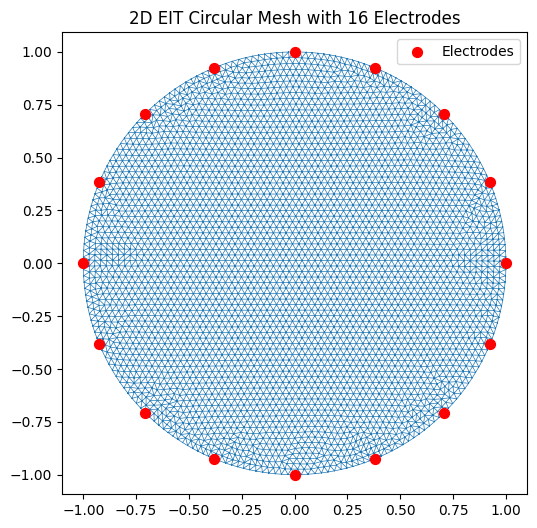

In [5]:
plt.figure(figsize=(6, 6))
plt.triplot(node[:, 0], node[:, 1], element, linewidth=0.5)
plt.scatter(node[el_pos, 0], node[el_pos, 1], c='red', s=50, label="Electrodes")
plt.title("2D EIT Circular Mesh with 16 Electrodes")
plt.axis("equal")
plt.legend()
plt.show()

In [6]:
def create_edema_case(center=(0.35, 0.25), radius=0.20, edema_perm=1.5):
    anomaly = PyEITAnomaly_Circle(
        center=np.array(center),
        r=radius,
        perm=edema_perm
    )

    mesh_edema = mesh.set_perm(
        mesh_obj,
        anomaly=anomaly,
        background=background_perm
    )

    return mesh_edema, anomaly

In [7]:
import copy
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# FREQUENCY-DEPENDENT 50 edema case generation
# Corrected:
# - 6 frequencies: 10, 50, 100, 200, 300, 400 kHz
# - tissue conductivity varies with frequency
# - whole conductivity curve varies by ±10% per case
# - edema location and size vary across 50 cases
# - edema is moved inward so it does NOT touch the outer boundary
# ---------------------------------------------------------

FREQS_KHZ = np.array([10, 50, 100, 200, 300, 400], dtype=np.float32)
REF_IDX = 0
REF_FREQ_KHZ = float(FREQS_KHZ[REF_IDX])

# Base conductivity curves from your numerical simulation table.
# Unit: S/m
BASE_SIGMA_FAT_CURVE = np.array([
    0.02283,
    0.024246,
    0.024414,
    0.024513,
    0.024585,
    0.024642
], dtype=np.float32)

BASE_SIGMA_MUSCLE_CURVE = np.array([
    0.34083,
    0.35182,
    0.36185,
    0.37265,
    0.38408,
    0.39563
], dtype=np.float32)

BASE_SIGMA_EDEMA_CURVE = np.array([
    0.04566,
    0.048492,
    0.048828,
    0.049026,
    0.049170,
    0.049284
], dtype=np.float32)

CONDUCTIVITY_VARIATION = 0.10
MUSCLE_BOUNDARY = 0.80
N_CASES = 50

# Important:
# Fat layer thickness is only 0.20 in normalized radius.
# To keep the full edema circle inside the fat layer and away from boundary,
# the radius must be small.
EDEMA_RADIUS_RANGE = (0.035, 0.050)
EDEMA_CLEARANCE = 0.055


MIN_EDEMA_ELEMENTS = 8

# PINN reconstruction support: prediction is not allowed near the outer boundary.
# This does NOT change the forward model. It only restricts the reconstruction output.
RECON_INNER_CLEARANCE = 0.005
RECON_OUTER_CLEARANCE = 0.035


def _mesh_center_and_radius(mesh_obj):
    node = mesh_obj.node[:, :2]
    cx = float(np.mean(node[:, 0]))
    cy = float(np.mean(node[:, 1]))
    r_node = np.sqrt((node[:, 0] - cx)**2 + (node[:, 1] - cy)**2)
    r_max = float(np.max(r_node))
    return cx, cy, r_max


def create_layered_leg_with_edema(
    mesh_obj,
    edema_center=(0.90, 0.10),
    edema_radius=0.025,
    sigma_fat=0.02283,
    sigma_muscle=0.34083,
    sigma_edema=0.04566,
    muscle_boundary=MUSCLE_BOUNDARY,
    verbose=True
):
    """
    Create 2D layered leg cross-section for one frequency.

    Healthy:
        inner 80% radius = muscle
        outer 20% radius = fat/subcutaneous layer

    Diseased:
        edema is assigned only where the circular edema mask overlaps fat.

    Important:
        No boundary-exclusion fat layer is created.
        The edema center is generated safely before this function,
        so the edema should not touch the outer boundary.
    """

    node = mesh_obj.node[:, :2]
    element = mesh_obj.element

    elem_center = np.mean(node[element], axis=1)
    x = elem_center[:, 0]
    y = elem_center[:, 1]

    cx, cy, r_max = _mesh_center_and_radius(mesh_obj)
    r_elem = np.sqrt((x - cx)**2 + (y - cy)**2)
    r_norm = r_elem / r_max

    # Full tissue layer masks
    muscle_mask = r_norm <= muscle_boundary
    fat_mask = r_norm > muscle_boundary

    # Assign all elements either fat or muscle. Never leave zero conductivity.
    perm_healthy = np.ones(element.shape[0], dtype=np.float32) * float(sigma_fat)
    perm_healthy[muscle_mask] = float(sigma_muscle)

    edema_center = np.asarray(edema_center, dtype=np.float32)

    dist = np.sqrt(
        (x - edema_center[0])**2 +
        (y - edema_center[1])**2
    )

    edema_mask_raw = dist <= edema_radius
    edema_mask = edema_mask_raw & fat_mask

    perm_edema = perm_healthy.copy()
    perm_edema[edema_mask] = float(sigma_edema)

    mesh_healthy = copy.deepcopy(mesh_obj)
    mesh_diseased = copy.deepcopy(mesh_obj)

    mesh_healthy.perm = perm_healthy
    mesh_diseased.perm = perm_edema

    if verbose:
        edema_r = r_norm[edema_mask]
        print("Layered leg model created")
        print("Muscle elements:", np.sum(muscle_mask))
        print("Fat elements:", np.sum(fat_mask))
        print("Edema elements:", np.sum(edema_mask))
        print("sigma_muscle:", sigma_muscle)
        print("sigma_fat:", sigma_fat)
        print("sigma_edema:", sigma_edema)
        print("Delta sigma:", sigma_edema - sigma_fat)
        print("Healthy conductivity values:", np.unique(perm_healthy))
        print("Diseased conductivity values:", np.unique(perm_edema))
        if edema_r.size > 0:
            print("Edema r_norm min:", float(edema_r.min()))
            print("Edema r_norm max:", float(edema_r.max()))

    assert np.all(perm_healthy > 0), "Healthy mesh contains zero conductivity."
    assert np.all(perm_edema > 0), "Edema mesh contains zero conductivity."

    return mesh_healthy, mesh_diseased, muscle_mask, fat_mask, edema_mask


def _element_geometry_for_sampling(mesh_obj):
    node = mesh_obj.node[:, :2]
    element = mesh_obj.element
    elem_center = np.mean(node[element], axis=1)

    cx, cy, r_max = _mesh_center_and_radius(mesh_obj)

    r_elem = np.sqrt((elem_center[:, 0] - cx)**2 + (elem_center[:, 1] - cy)**2)
    r_norm = r_elem / r_max

    fat_mask = r_norm > MUSCLE_BOUNDARY

    return elem_center, r_norm, fat_mask, cx, cy, r_max


def generate_safe_edema_center(
    mesh_obj,
    rng,
    angle,
    radius_range=EDEMA_RADIUS_RANGE,
    muscle_boundary=MUSCLE_BOUNDARY,
    clearance=EDEMA_CLEARANCE,
    max_tries=1000
):
    """
    Generate edema center and radius such that the full edema circle:
    - stays inside the fat layer
    - does not touch the muscle-fat boundary
    - does not touch the outer boundary

    This only adjusts center and width/radius.
    It does not create a new fat boundary layer.
    """

    cx, cy, r_max = _mesh_center_and_radius(mesh_obj)

    for _ in range(max_tries):
        edema_radius = float(rng.uniform(radius_range[0], radius_range[1]))
        radius_norm = edema_radius / r_max

        # Safe radial interval for the edema center.
        r_center_min = muscle_boundary + radius_norm + clearance
        r_center_max = 1.0 - radius_norm - clearance

        if r_center_min >= r_center_max:
            continue

        # Center in the middle-safe band of the fat layer.
        r_center_norm = float(rng.uniform(r_center_min, r_center_max))

        edema_center = np.array([
            cx + r_center_norm * r_max * np.cos(angle),
            cy + r_center_norm * r_max * np.sin(angle)
        ], dtype=np.float32)

        inner_clearance = r_center_norm - radius_norm - muscle_boundary
        outer_clearance = 1.0 - (r_center_norm + radius_norm)

        return edema_center, edema_radius, inner_clearance, outer_clearance

    raise RuntimeError(
        "Could not generate safe edema. Reduce radius_range or clearance."
    )


def generate_frequency_dependent_edema_cases(mesh_obj, n_cases=50, seed=42):
    """
    Generate independent edema cases:
    - different edema center inside fat layer
    - different edema radius
    - edema does not touch outer boundary
    - conductivity curves varied by ±10%
    """
    rng = np.random.default_rng(seed)
    elem_center, r_norm_elem, fat_mask_base, cx, cy, r_max = _element_geometry_for_sampling(mesh_obj)

    cases = []

    for case_idx in range(1, n_cases + 1):

        fat_scale = rng.uniform(1.0 - CONDUCTIVITY_VARIATION, 1.0 + CONDUCTIVITY_VARIATION)
        muscle_scale = rng.uniform(1.0 - CONDUCTIVITY_VARIATION, 1.0 + CONDUCTIVITY_VARIATION)
        edema_scale = rng.uniform(1.0 - CONDUCTIVITY_VARIATION, 1.0 + CONDUCTIVITY_VARIATION)

        sigma_fat_curve = BASE_SIGMA_FAT_CURVE * fat_scale
        sigma_muscle_curve = BASE_SIGMA_MUSCLE_CURVE * muscle_scale
        sigma_edema_curve = BASE_SIGMA_EDEMA_CURVE * edema_scale

        # Safety: edema conductivity must remain higher than fat.
        sigma_edema_curve = np.maximum(sigma_edema_curve, 1.20 * sigma_fat_curve)

        base_angle = 2.0 * np.pi * (case_idx - 1) / n_cases
        angle = base_angle + rng.uniform(-np.pi / n_cases, np.pi / n_cases)

        selected = None

        for attempt in range(1000):
            edema_center, edema_radius, inner_clearance, outer_clearance = generate_safe_edema_center(
                mesh_obj,
                rng=rng,
                angle=angle,
                radius_range=EDEMA_RADIUS_RANGE,
                muscle_boundary=MUSCLE_BOUNDARY,
                clearance=EDEMA_CLEARANCE
            )

            dist = np.sqrt(
                (elem_center[:, 0] - edema_center[0])**2 +
                (elem_center[:, 1] - edema_center[1])**2
            )

            edema_mask_try = (dist <= edema_radius) & fat_mask_base
            edema_elements = int(np.sum(edema_mask_try))

            if edema_elements >= MIN_EDEMA_ELEMENTS:
                selected = (
                    edema_center,
                    edema_radius,
                    edema_elements,
                    inner_clearance,
                    outer_clearance
                )
                break

        if selected is None:
            raise RuntimeError(f"Could not create enough edema elements for case {case_idx}")

        edema_center, edema_radius, edema_elements, inner_clearance, outer_clearance = selected

        delta_sigma_ref = float(sigma_edema_curve[REF_IDX] - sigma_fat_curve[REF_IDX])

        case = {
            "case_id": f"case_{case_idx:03d}_v2",
            "edema_center": (float(edema_center[0]), float(edema_center[1])),
            "edema_radius": float(edema_radius),

            "sigma_fat_curve": sigma_fat_curve.astype(float).tolist(),
            "sigma_muscle_curve": sigma_muscle_curve.astype(float).tolist(),
            "sigma_edema_curve": sigma_edema_curve.astype(float).tolist(),

            "sigma_fat": float(sigma_fat_curve[REF_IDX]),
            "sigma_muscle": float(sigma_muscle_curve[REF_IDX]),
            "sigma_edema": float(sigma_edema_curve[REF_IDX]),
            "delta_sigma_max": delta_sigma_ref,

            "fat_scale": float(fat_scale),
            "muscle_scale": float(muscle_scale),
            "edema_scale": float(edema_scale),
            "estimated_edema_elements": int(edema_elements),
            "inner_clearance": float(inner_clearance),
            "outer_clearance": float(outer_clearance)
        }

        cases.append(case)

    return cases


CASE_LIST = generate_frequency_dependent_edema_cases(
    mesh_obj,
    n_cases=N_CASES,
    seed=SEED if "SEED" in globals() else 42
)

case_table = pd.DataFrame(CASE_LIST)

print("Generated frequency-dependent edema cases:", len(CASE_LIST))
print("Frequencies kHz:", FREQS_KHZ)
print("Edema radius range:", EDEMA_RADIUS_RANGE)
print("Edema clearance:", EDEMA_CLEARANCE)
print("Reconstruction outer clearance:", RECON_OUTER_CLEARANCE)

display(case_table[[
    "case_id", "edema_center", "edema_radius",
    "inner_clearance", "outer_clearance",
    "sigma_fat", "sigma_muscle", "sigma_edema",
    "delta_sigma_max", "estimated_edema_elements"
]].head())


Generated frequency-dependent edema cases: 50
Frequencies kHz: [ 10.  50. 100. 200. 300. 400.]
Edema radius range: (0.035, 0.05)
Edema clearance: 0.055
Reconstruction outer clearance: 0.035


,case_id,edema_center,edema_radius,inner_clearance,outer_clearance,sigma_fat,sigma_muscle,sigma_edema,delta_sigma_max,estimated_edema_elements
0,case_001_v2,"(0.9090732932090759, 0.02198767475783825)",0.036413,0.071808,0.055420,0.024081,0.336664,0.048935,0.024854,12
1,case_002_v2,"(0.898526132106781, 0.10721287876367569)",0.040562,0.063281,0.055654,0.024022,0.360330,0.042264,0.018242,14
2,case_003_v2,"(0.8785595893859863, 0.19308502972126007)",0.043319,0.055219,0.058208,0.023487,0.362831,0.045143,0.021656,15
3,case_004_v2,"(0.8433823585510254, 0.31547531485557556)",0.037920,0.061635,0.062581,0.024326,0.349805,0.048017,0.023691,12
4,case_005_v2,"(0.7748816609382629, 0.45673513412475586)",0.039887,0.058810,0.061474,0.020747,0.317264,0.047332,0.026585,12


In [8]:
# ---------------------------------------------------------
# Run first frequency-dependent edema case only
# After checking case_001 output, use the final cell to run cases 002-050.
# ---------------------------------------------------------

CURRENT_CASE_INDEX = 0
CURRENT_CASE = CASE_LIST[CURRENT_CASE_INDEX]
CASE_ID = CURRENT_CASE["case_id"]

print("Running first case only:", CASE_ID)
print("Frequencies kHz:", FREQS_KHZ)

freq_table = pd.DataFrame({
    "frequency_kHz": FREQS_KHZ,
    "sigma_fat": CURRENT_CASE["sigma_fat_curve"],
    "sigma_muscle": CURRENT_CASE["sigma_muscle_curve"],
    "sigma_edema": CURRENT_CASE["sigma_edema_curve"],
})
freq_table["delta_sigma"] = freq_table["sigma_edema"] - freq_table["sigma_fat"]
display(freq_table)

edema_center = CURRENT_CASE["edema_center"]
edema_radius = CURRENT_CASE["edema_radius"]

# Reference 10 kHz meshes kept for the old plotting and PINN cells.
mesh_healthy, mesh_edema, muscle_mask, fat_mask, edema_mask = create_layered_leg_with_edema(
    mesh_obj,
    edema_center=edema_center,
    edema_radius=edema_radius,
    sigma_fat=CURRENT_CASE["sigma_fat"],
    sigma_muscle=CURRENT_CASE["sigma_muscle"],
    sigma_edema=CURRENT_CASE["sigma_edema"],
    muscle_boundary=MUSCLE_BOUNDARY,
    verbose=True
)

# Case-specific output contrast scale at reference frequency.
# The PINN architecture is unchanged.
DELTA_SIGMA_MAX = CURRENT_CASE["delta_sigma_max"]

print("Active DELTA_SIGMA_MAX at 10 kHz:", DELTA_SIGMA_MAX)


Running first case only: case_001_v2
Frequencies kHz: [ 10.  50. 100. 200. 300. 400.]


,frequency_kHz,sigma_fat,sigma_muscle,sigma_edema,delta_sigma
0,10.0,0.024081,0.336664,0.048935,0.024854
1,50.0,0.025574,0.347519,0.051970,0.026395
2,100.0,0.025752,0.357427,0.052330,0.026578
3,200.0,0.025856,0.368095,0.052542,0.026686
4,300.0,0.025932,0.379385,0.052696,0.026764
5,400.0,0.025992,0.390794,0.052819,0.026826


Layered leg model created
Muscle elements: 5039
Fat elements: 2862
Edema elements: 12
sigma_muscle: 0.3366635739803314
sigma_fat: 0.024080883711576462
sigma_edema: 0.04893471300601959
Delta sigma: 0.02485382929444313
Healthy conductivity values: [0.02408088 0.33666357]
Diseased conductivity values: [0.02408088 0.04893471 0.33666357]
Edema r_norm min: 0.8766789702791422
Edema r_norm max: 0.9331746978964727
Active DELTA_SIGMA_MAX at 10 kHz: 0.02485382929444313


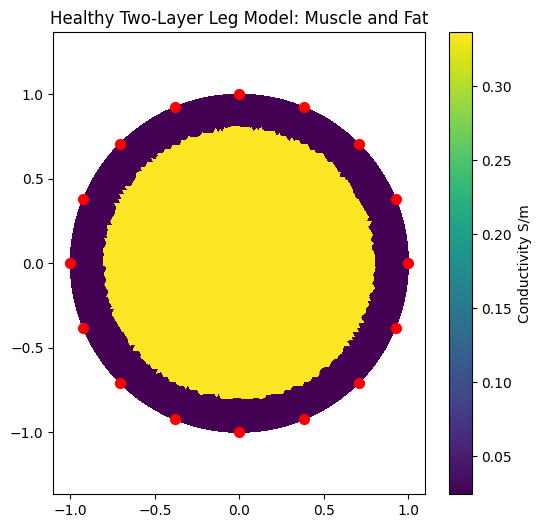

In [9]:
plt.figure(figsize=(6, 6))

plt.tripcolor(
    node[:, 0],
    node[:, 1],
    element,
    mesh_healthy.perm,
    shading="flat"
)

plt.colorbar(label="Conductivity S/m")
plt.scatter(node[el_pos, 0], node[el_pos, 1], c="red", s=50)
plt.title("Healthy Two-Layer Leg Model: Muscle and Fat")
plt.axis("equal")
plt.show()

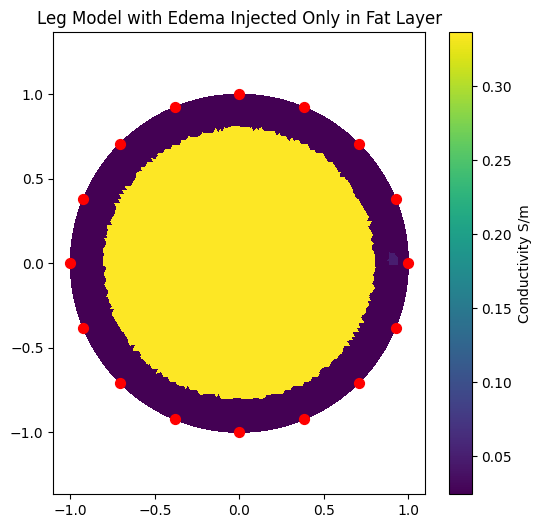

In [10]:
plt.figure(figsize=(6, 6))

plt.tripcolor(
    node[:, 0],
    node[:, 1],
    element,
    mesh_edema.perm,
    shading="flat"
)

plt.colorbar(label="Conductivity S/m")
plt.scatter(node[el_pos, 0], node[el_pos, 1], c="red", s=50)
plt.title("Leg Model with Edema Injected Only in Fat Layer")
plt.axis("equal")
plt.show()

In [11]:
# ---------------------------------------------------------
# Save generated 50-case metadata
# ---------------------------------------------------------

from pathlib import Path
import json
import pandas as pd

DATASET_DIR = Path.cwd() / "results" / "frequency_edema_dataset"
DATASET_DIR.mkdir(parents=True, exist_ok=True)

# Save CASE_LIST as CSV
case_table = pd.DataFrame(CASE_LIST)

metadata_csv_path = DATASET_DIR / "frequency_edema_50_cases_metadata.csv"
case_table.to_csv(metadata_csv_path, index=False)

# Save CASE_LIST as JSON
metadata_json_path = DATASET_DIR / "frequency_edema_50_cases_metadata.json"
with open(metadata_json_path, "w") as f:
    json.dump(CASE_LIST, f, indent=2)

print("Saved metadata CSV:", metadata_csv_path)
print("Saved metadata JSON:", metadata_json_path)

display(case_table.head())

Saved metadata CSV: /notebooks/gitupload/results/frequency_edema_dataset/frequency_edema_50_cases_metadata.csv
Saved metadata JSON: /notebooks/gitupload/results/frequency_edema_dataset/frequency_edema_50_cases_metadata.json


,case_id,edema_center,edema_radius,sigma_fat_curve,sigma_muscle_curve,sigma_edema_curve,sigma_fat,sigma_muscle,sigma_edema,delta_sigma_max,fat_scale,muscle_scale,edema_scale,estimated_edema_elements,inner_clearance,outer_clearance
0,case_001_v2,"(0.9090732932090759, 0.02198767475783825)",0.036413,"[0.024080883711576462, 0.025574468076229095, 0...","[0.3366635739803314, 0.3475192189216614, 0.357...","[0.04893471300601959, 0.051969822496175766, 0....",0.024081,0.336664,0.048935,0.024854,1.054791,0.987776,1.071720,12,0.071808,0.055420
1,case_002_v2,"(0.898526132106781, 0.10721287876367569)",0.040562,"[0.024022364988923073, 0.025512319058179855, 0...","[0.36032983660697937, 0.37194859981536865, 0.3...","[0.0422639325261116, 0.0448852963745594, 0.045...",0.024022,0.360330,0.042264,0.018242,1.052228,1.057213,0.925623,14,0.063281,0.055654
2,case_003_v2,"(0.8785595893859863, 0.19308502972126007)",0.043319,"[0.023486889898777008, 0.024943631142377853, 0...","[0.36283135414123535, 0.3745307922363281, 0.38...","[0.045143261551856995, 0.04794320836663246, 0....",0.023487,0.362831,0.045143,0.021656,1.028773,1.064552,0.988683,15,0.055219,0.058208
3,case_004_v2,"(0.8433823585510254, 0.31547531485557556)",0.037920,"[0.024325964972376823, 0.02583474852144718, 0....","[0.3498050272464752, 0.3610844314098358, 0.371...","[0.048016857355833054, 0.05099503695964813, 0....",0.024326,0.349805,0.048017,0.023691,1.065526,1.026333,1.051618,12,0.061635,0.062581
4,case_005_v2,"(0.7748816609382629, 0.45673513412475586)",0.039887,"[0.020747007802128792, 0.0220338124781847, 0.0...","[0.31726428866386414, 0.32749441266059875, 0.3...","[0.04733160138130188, 0.05026727914810181, 0.0...",0.020747,0.317264,0.047332,0.026585,0.908761,0.930858,1.036610,12,0.058810,0.061474


In [12]:
# ---------------------------------------------------------
# Frequency-dependent forward simulation
# Generates 6 healthy voltages and 6 edema voltages:
# V0_all shape = [6, measurements]
# V1_all shape = [6, measurements]
# ---------------------------------------------------------

def solve_all_frequency_voltages(case_config, verbose=True):
    """
    Solve forward EIT voltages for all 6 frequencies.

    Returns:
        V0_all: healthy voltages, shape [6, M]
        V1_all: edema voltages, shape [6, M]
        meshes_healthy_all: healthy mesh for each frequency
        meshes_edema_all: edema mesh for each frequency
        masks_ref: masks from reference frequency
    """

    V0_all = []
    V1_all = []

    meshes_healthy_all = []
    meshes_edema_all = []

    masks_ref = None

    sigma_fat_curve = np.asarray(case_config["sigma_fat_curve"], dtype=np.float32)
    sigma_muscle_curve = np.asarray(case_config["sigma_muscle_curve"], dtype=np.float32)
    sigma_edema_curve = np.asarray(case_config["sigma_edema_curve"], dtype=np.float32)

    for k, freq_khz in enumerate(FREQS_KHZ):

        mesh_h_f, mesh_e_f, muscle_mask_f, fat_mask_f, edema_mask_f = create_layered_leg_with_edema(
            mesh_obj,
            edema_center=case_config["edema_center"],
            edema_radius=case_config["edema_radius"],
            sigma_fat=float(sigma_fat_curve[k]),
            sigma_muscle=float(sigma_muscle_curve[k]),
            sigma_edema=float(sigma_edema_curve[k]),
            muscle_boundary=MUSCLE_BOUNDARY,
            verbose=False
        )

        fwd = EITForward(mesh_obj, protocol_obj)

        v0_f = fwd.solve_eit(perm=mesh_h_f.perm)
        v1_f = fwd.solve_eit(perm=mesh_e_f.perm)

        V0_all.append(v0_f)
        V1_all.append(v1_f)

        meshes_healthy_all.append(mesh_h_f)
        meshes_edema_all.append(mesh_e_f)

        if k == REF_IDX:
            masks_ref = (muscle_mask_f, fat_mask_f, edema_mask_f)

    V0_all = np.asarray(V0_all, dtype=np.float32)
    V1_all = np.asarray(V1_all, dtype=np.float32)

    if verbose:
        print("Frequencies kHz:", FREQS_KHZ)
        print("Healthy voltage matrix V0_all:", V0_all.shape)
        print("Edema voltage matrix V1_all:", V1_all.shape)
        print("Reference frequency:", REF_FREQ_KHZ, "kHz")
        print("One frequency measurement count:", V0_all.shape[1])

    return V0_all, V1_all, meshes_healthy_all, meshes_edema_all, masks_ref


# Solve voltages for case_001 at 6 frequencies.
V0_all, V1_all, meshes_healthy_all, meshes_edema_all, masks_ref = solve_all_frequency_voltages(
    CURRENT_CASE,
    verbose=True
)

# These are reference-frequency healthy and edema voltages.
v0 = V0_all[REF_IDX]
v1 = V1_all[REF_IDX]
delta_v = v1 - v0

print("Reference healthy voltage shape:", v0.shape)
print("Reference edema voltage shape:", v1.shape)
print("Reference condition-difference voltage shape:", delta_v.shape)


Frequencies kHz: [ 10.  50. 100. 200. 300. 400.]
Healthy voltage matrix V0_all: (6, 208)
Edema voltage matrix V1_all: (6, 208)
Reference frequency: 10.0 kHz
One frequency measurement count: 208
Reference healthy voltage shape: (208,)
Reference edema voltage shape: (208,)
Reference condition-difference voltage shape: (208,)


In [13]:
# ---------------------------------------------------------
# Weighted frequency-difference voltage input
# ---------------------------------------------------------

def add_noise(signal, snr_db=40):
    """
    Add Gaussian noise according to SNR.
    Returns signal + noise.
    """
    signal = np.asarray(signal)
    signal_power = np.linalg.norm(signal) / np.sqrt(signal.size)
    noise_std = signal_power / (10 ** (snr_db / 20))
    noise = np.random.normal(0, noise_std, signal.shape)
    return signal + noise


def alpha_scale(v_ref, v_f):
    """
    Weighted scaling factor:
    alpha = <V_ref, V_f> / <V_ref, V_ref>
    """
    return float(np.dot(v_f, v_ref) / (np.dot(v_ref, v_ref) + 1e-12))


def build_weighted_frequency_difference_input(
    V0_all,
    V1_all,
    ref_idx=0,
    snr_db=40,
    verbose=True
):
    """
    Build stacked frequency-difference voltage input.

    For each higher frequency f:
        FD_healthy(f) = V0_f - alpha_f * V0_ref
        FD_edema(f)   = V1_f - alpha_f * V1_ref

    To isolate edema-induced frequency response:
        ΔV_fd(f) = FD_edema(f) - FD_healthy(f)

    Finally concatenate all higher-frequency blocks:
        dv_frequency_input shape = [(num_freq - 1) * measurements]
    """

    v0_ref = V0_all[ref_idx]
    v1_ref = V1_all[ref_idx]

    fd_healthy_blocks = []
    fd_edema_blocks = []
    dv_fd_blocks = []
    alpha_values = []

    for k, freq_khz in enumerate(FREQS_KHZ):

        if k == ref_idx:
            continue

        v0_f = V0_all[k]
        v1_f = V1_all[k]

        # Alpha is computed from healthy voltages to normalize global amplitude change.
        alpha = alpha_scale(v0_ref, v0_f)
        alpha_values.append(alpha)

        fd_healthy = v0_f - alpha * v0_ref
        fd_edema = v1_f - alpha * v1_ref

        # Edema-induced weighted frequency-difference voltage.
        dv_fd = fd_edema - fd_healthy

        # Add noise to the final difference signal, not directly to absolute V.
        dv_fd_noisy = add_noise(dv_fd, snr_db=snr_db)

        fd_healthy_blocks.append(fd_healthy)
        fd_edema_blocks.append(fd_edema)
        dv_fd_blocks.append(dv_fd_noisy)

    fd_healthy_blocks = np.asarray(fd_healthy_blocks, dtype=np.float32)
    fd_edema_blocks = np.asarray(fd_edema_blocks, dtype=np.float32)
    dv_fd_blocks = np.asarray(dv_fd_blocks, dtype=np.float32)

    dv_frequency_input = np.concatenate(dv_fd_blocks, axis=0).astype(np.float32)

    if verbose:
        print("Alpha values for higher frequencies:", alpha_values)
        print("FD healthy blocks:", fd_healthy_blocks.shape)
        print("FD edema blocks:", fd_edema_blocks.shape)
        print("FD edema-induced blocks:", dv_fd_blocks.shape)
        print("Stacked dv_frequency_input:", dv_frequency_input.shape)

    return dv_frequency_input, fd_healthy_blocks, fd_edema_blocks, dv_fd_blocks, np.asarray(alpha_values)


snr_db = 40

dv_frequency_input, fd_healthy_blocks, fd_edema_blocks, dv_fd_blocks, alpha_values = \
    build_weighted_frequency_difference_input(
        V0_all,
        V1_all,
        ref_idx=REF_IDX,
        snr_db=snr_db,
        verbose=True
    )

# The actual PINN input below will use dv_frequency_input.
v1_noisy = v0 + add_noise(delta_v, snr_db=snr_db)

print("Frequency-dependent noisy input generated.")


Alpha values for higher frequencies: [0.9471351817782895, 0.9365049938151143, 0.9279231594946025, 0.9201774333071155, 0.9131463928648051]
FD healthy blocks: (5, 208)
FD edema blocks: (5, 208)
FD edema-induced blocks: (5, 208)
Stacked dv_frequency_input: (1040,)
Frequency-dependent noisy input generated.


In [14]:
# ---------------------------------------------------------
# Save full generated frequency-dependent EIT dataset
# ---------------------------------------------------------

DATASET_DIR = Path.cwd() / "results" / "frequency_edema_dataset"
DATASET_DIR.mkdir(parents=True, exist_ok=True)

FULL_DATASET_FILE = DATASET_DIR / "frequency_edema_50_cases_full_dataset.npz"

all_case_ids = []
all_edema_centers = []
all_edema_radii = []

all_sigma_fat_curves = []
all_sigma_muscle_curves = []
all_sigma_edema_curves = []

all_delta_sigma_ref = []
all_edema_elements = []

all_V0 = []
all_V1 = []
all_dv_frequency_input = []

all_fd_healthy_blocks = []
all_fd_edema_blocks = []
all_dv_fd_blocks = []
all_alpha_values = []

all_perm_healthy_ref = []
all_perm_edema_ref = []
all_delta_sigma_true_ref = []

all_muscle_masks = []
all_fat_masks = []
all_edema_masks = []

for case_config in CASE_LIST:

    print("Saving dataset for:", case_config["case_id"])

    # -----------------------------------------------------
    # Reference 10 kHz mesh and masks
    # -----------------------------------------------------
    mesh_healthy_ref, mesh_edema_ref, muscle_mask_ref, fat_mask_ref, edema_mask_ref = create_layered_leg_with_edema(
        mesh_obj,
        edema_center=case_config["edema_center"],
        edema_radius=case_config["edema_radius"],
        sigma_fat=case_config["sigma_fat"],
        sigma_muscle=case_config["sigma_muscle"],
        sigma_edema=case_config["sigma_edema"],
        muscle_boundary=MUSCLE_BOUNDARY,
        verbose=False
    )

    delta_sigma_true_ref = mesh_edema_ref.perm - mesh_healthy_ref.perm

    # -----------------------------------------------------
    # Six-frequency forward voltages
    # -----------------------------------------------------
    V0_all, V1_all, meshes_healthy_all, meshes_edema_all, masks_ref = solve_all_frequency_voltages(
        case_config,
        verbose=False
    )

    # -----------------------------------------------------
    # Frequency-difference voltage input
    # -----------------------------------------------------
    dv_frequency_input, fd_healthy_blocks, fd_edema_blocks, dv_fd_blocks, alpha_values = \
        build_weighted_frequency_difference_input(
            V0_all,
            V1_all,
            ref_idx=REF_IDX,
            snr_db=snr_db,
            verbose=False
        )

    # -----------------------------------------------------
    # Store case information
    # -----------------------------------------------------
    all_case_ids.append(case_config["case_id"])
    all_edema_centers.append(case_config["edema_center"])
    all_edema_radii.append(case_config["edema_radius"])

    all_sigma_fat_curves.append(case_config["sigma_fat_curve"])
    all_sigma_muscle_curves.append(case_config["sigma_muscle_curve"])
    all_sigma_edema_curves.append(case_config["sigma_edema_curve"])

    all_delta_sigma_ref.append(case_config["delta_sigma_max"])
    all_edema_elements.append(int(np.sum(edema_mask_ref)))

    all_V0.append(V0_all)
    all_V1.append(V1_all)
    all_dv_frequency_input.append(dv_frequency_input)

    all_fd_healthy_blocks.append(fd_healthy_blocks)
    all_fd_edema_blocks.append(fd_edema_blocks)
    all_dv_fd_blocks.append(dv_fd_blocks)
    all_alpha_values.append(alpha_values)

    all_perm_healthy_ref.append(mesh_healthy_ref.perm)
    all_perm_edema_ref.append(mesh_edema_ref.perm)
    all_delta_sigma_true_ref.append(delta_sigma_true_ref)

    all_muscle_masks.append(muscle_mask_ref)
    all_fat_masks.append(fat_mask_ref)
    all_edema_masks.append(edema_mask_ref)


# ---------------------------------------------------------
# Convert to arrays and save
# ---------------------------------------------------------

np.savez_compressed(
    FULL_DATASET_FILE,

    # Basic case information
    case_ids=np.array(all_case_ids),
    edema_centers=np.array(all_edema_centers, dtype=np.float32),
    edema_radii=np.array(all_edema_radii, dtype=np.float32),

    # Frequencies
    freqs_khz=FREQS_KHZ.astype(np.float32),
    ref_idx=np.array([REF_IDX], dtype=np.int32),

    # Conductivity curves
    sigma_fat_curves=np.array(all_sigma_fat_curves, dtype=np.float32),
    sigma_muscle_curves=np.array(all_sigma_muscle_curves, dtype=np.float32),
    sigma_edema_curves=np.array(all_sigma_edema_curves, dtype=np.float32),

    # Reference contrast
    delta_sigma_ref=np.array(all_delta_sigma_ref, dtype=np.float32),
    edema_elements=np.array(all_edema_elements, dtype=np.int32),

    # Voltage data
    V0_all=np.array(all_V0, dtype=np.float32),
    V1_all=np.array(all_V1, dtype=np.float32),
    dv_frequency_input=np.array(all_dv_frequency_input, dtype=np.float32),

    # Frequency-difference blocks
    fd_healthy_blocks=np.array(all_fd_healthy_blocks, dtype=np.float32),
    fd_edema_blocks=np.array(all_fd_edema_blocks, dtype=np.float32),
    dv_fd_blocks=np.array(all_dv_fd_blocks, dtype=np.float32),
    alpha_values=np.array(all_alpha_values, dtype=np.float32),

    # Conductivity maps at reference frequency
    perm_healthy_ref=np.array(all_perm_healthy_ref, dtype=np.float32),
    perm_edema_ref=np.array(all_perm_edema_ref, dtype=np.float32),
    delta_sigma_true_ref=np.array(all_delta_sigma_true_ref, dtype=np.float32),

    # Masks
    muscle_masks=np.array(all_muscle_masks, dtype=np.bool_),
    fat_masks=np.array(all_fat_masks, dtype=np.bool_),
    edema_masks=np.array(all_edema_masks, dtype=np.bool_),
)

print("Full dataset saved to:", FULL_DATASET_FILE)

Saving dataset for: case_001_v2
Saving dataset for: case_002_v2
Saving dataset for: case_003_v2
Saving dataset for: case_004_v2
Saving dataset for: case_005_v2
Saving dataset for: case_006_v2
Saving dataset for: case_007_v2
Saving dataset for: case_008_v2
Saving dataset for: case_009_v2
Saving dataset for: case_010_v2
Saving dataset for: case_011_v2
Saving dataset for: case_012_v2
Saving dataset for: case_013_v2
Saving dataset for: case_014_v2
Saving dataset for: case_015_v2
Saving dataset for: case_016_v2
Saving dataset for: case_017_v2
Saving dataset for: case_018_v2
Saving dataset for: case_019_v2
Saving dataset for: case_020_v2
Saving dataset for: case_021_v2
Saving dataset for: case_022_v2
Saving dataset for: case_023_v2
Saving dataset for: case_024_v2
Saving dataset for: case_025_v2
Saving dataset for: case_026_v2
Saving dataset for: case_027_v2
Saving dataset for: case_028_v2
Saving dataset for: case_029_v2
Saving dataset for: case_030_v2
Saving dataset for: case_031_v2
Saving d

In [15]:
# ---------------------------------------------------------
# Check saved dataset
# ---------------------------------------------------------

data = np.load(FULL_DATASET_FILE, allow_pickle=True)

print("Available keys:")
print(data.files)

print("Number of cases:", len(data["case_ids"]))
print("Frequencies:", data["freqs_khz"])

print("V0_all shape:", data["V0_all"].shape)
print("V1_all shape:", data["V1_all"].shape)
print("dv_frequency_input shape:", data["dv_frequency_input"].shape)

print("sigma_fat_curves shape:", data["sigma_fat_curves"].shape)
print("sigma_muscle_curves shape:", data["sigma_muscle_curves"].shape)
print("sigma_edema_curves shape:", data["sigma_edema_curves"].shape)

print("edema_masks shape:", data["edema_masks"].shape)
print("delta_sigma_true_ref shape:", data["delta_sigma_true_ref"].shape)

Available keys:
['case_ids', 'edema_centers', 'edema_radii', 'freqs_khz', 'ref_idx', 'sigma_fat_curves', 'sigma_muscle_curves', 'sigma_edema_curves', 'delta_sigma_ref', 'edema_elements', 'V0_all', 'V1_all', 'dv_frequency_input', 'fd_healthy_blocks', 'fd_edema_blocks', 'dv_fd_blocks', 'alpha_values', 'perm_healthy_ref', 'perm_edema_ref', 'delta_sigma_true_ref', 'muscle_masks', 'fat_masks', 'edema_masks']
Number of cases: 50
Frequencies: [ 10.  50. 100. 200. 300. 400.]
V0_all shape: (50, 6, 208)
V1_all shape: (50, 6, 208)
dv_frequency_input shape: (50, 1040)
sigma_fat_curves shape: (50, 6)
sigma_muscle_curves shape: (50, 6)
sigma_edema_curves shape: (50, 6)
edema_masks shape: (50, 7901)
delta_sigma_true_ref shape: (50, 7901)


In [16]:
import os
import json
import time
import copy
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import pyeit.eit.jac as jac

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Using device: cuda
GPU name: NVIDIA RTX A4000


In [18]:
# ---------------------------------------------------------
# Paths and training configuration
# ---------------------------------------------------------

PROJECT_ROOT = Path.cwd()

RESULTS_DIR = PROJECT_ROOT / "results"
PINN_DIR = RESULTS_DIR / "pinn_fat_layer"
CHECKPOINT_DIR = PINN_DIR / "checkpoints"
FIG_DIR = PINN_DIR / "figures"
LOG_DIR = PINN_DIR / "logs"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

# Use active case. The generated case_id has support_v4 so old checkpoints are not reused.
CASE_ID = CURRENT_CASE["case_id"] if "CURRENT_CASE" in globals() else "case_001_v2"

BEST_MODEL_FILE = CHECKPOINT_DIR / f"best_pinn_{CASE_ID}.pt"
LATEST_MODEL_FILE = CHECKPOINT_DIR / f"latest_pinn_{CASE_ID}.pt"
TRAIN_HISTORY_FILE = LOG_DIR / f"train_history_{CASE_ID}.json"
TRAIN_OUTPUT_FILE = CHECKPOINT_DIR / f"pinn_train_output_{CASE_ID}.npz"

# Training configuration
EPOCHS = 20000
LR = 1e-3
PRINT_EVERY = 1000
SAVE_EVERY = 500

# ---------------------------------------------------------
# Refined loss weights
# These keep your PINN model/loss style, but add reconstruction support.
# ---------------------------------------------------------

LAMBDA_SUP = 500.0
LAMBDA_DATA = 1.0
LAMBDA_SMOOTH = 5e-7
LAMBDA_PRIOR = 0.0
LAMBDA_BG = 150.0
LAMBDA_SPARSE = 3e-3

# Case-specific edema contrast from the generated case.
DELTA_SIGMA_MAX = CURRENT_CASE["delta_sigma_max"] if "CURRENT_CASE" in globals() else 0.023

print("Best model file:", BEST_MODEL_FILE)
print("Latest model file:", LATEST_MODEL_FILE)
print("History file:", TRAIN_HISTORY_FILE)
print("DELTA_SIGMA_MAX:", DELTA_SIGMA_MAX)
print("Loss weights:")
print("  LAMBDA_SUP:", LAMBDA_SUP)
print("  LAMBDA_DATA:", LAMBDA_DATA)
print("  LAMBDA_SMOOTH:", LAMBDA_SMOOTH)
print("  LAMBDA_BG:", LAMBDA_BG)
print("  LAMBDA_SPARSE:", LAMBDA_SPARSE)


Best model file: /notebooks/gitupload/results/pinn_fat_layer/checkpoints/best_pinn_case_001_v2.pt
Latest model file: /notebooks/gitupload/results/pinn_fat_layer/checkpoints/latest_pinn_case_001_v2.pt
History file: /notebooks/gitupload/results/pinn_fat_layer/logs/train_history_case_001_v2.json
DELTA_SIGMA_MAX: 0.02485382929444313
Loss weights:
  LAMBDA_SUP: 500.0
  LAMBDA_DATA: 1.0
  LAMBDA_SMOOTH: 5e-07
  LAMBDA_BG: 150.0
  LAMBDA_SPARSE: 0.003


In [19]:
# ---------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Seed set to:", SEED)

Seed set to: 42


In [20]:
# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------

def save_json(filepath, obj):
    with open(filepath, "w") as f:
        json.dump(obj, f, indent=2)


def to_tensor(x, dtype=torch.float32):
    return torch.tensor(x, dtype=dtype, device=device)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def print_stats(name, arr):
    arr = np.asarray(arr)
    print(
        f"{name}: shape={arr.shape}, "
        f"min={arr.min():.6e}, max={arr.max():.6e}, "
        f"mean={arr.mean():.6e}, std={arr.std():.6e}"
    )

In [21]:
# ---------------------------------------------------------
# Build PINN dataset
# ---------------------------------------------------------

required_vars = [
    "mesh_obj", "protocol_obj", "mesh_healthy", "mesh_edema",
    "fat_mask", "edema_mask", "dv_frequency_input"
]

missing = [name for name in required_vars if name not in globals()]
if missing:
    raise NameError(f"Missing variables cells: {missing}")

node_2d = mesh_obj.node[:, :2]
element = mesh_obj.element
n_elements = element.shape[0]

# Element center coordinates
region_coords_raw = np.mean(node_2d[element], axis=1).astype(np.float32)

x = region_coords_raw[:, 0]
y = region_coords_raw[:, 1]

cx = np.mean(node_2d[:, 0])
cy = np.mean(node_2d[:, 1])

r_node = np.sqrt((node_2d[:, 0] - cx)**2 + (node_2d[:, 1] - cy)**2)
r_max = np.max(r_node)

x_norm = (x - cx) / r_max
y_norm = (y - cy) / r_max
r_norm = np.sqrt(x_norm**2 + y_norm**2)

# Neural input remains only x and y.
# Do not add r_norm to PINN input.
X_input = np.stack([x_norm, y_norm], axis=1).astype(np.float32)

# True conductivity change at the reference frequency, 10 kHz.
delta_sigma_true = (mesh_edema.perm - mesh_healthy.perm).astype(np.float32)
sigma_true = mesh_edema.perm.astype(np.float32)

# Frequency-dependent voltage input.
dv = dv_frequency_input.astype(np.float32)

# Element-wise masks
fat_mask_np = np.asarray(fat_mask).astype(bool)
edema_mask_np = np.asarray(edema_mask).astype(bool)

# ---------------------------------------------------------
# Reconstruction support mask
# Forward model still uses full fat layer.
# PINN reconstruction is allowed only inside this support region.
# This prevents reconstructed edema from touching outer boundary.
# ---------------------------------------------------------

recon_support_mask_np = (
    (r_norm > MUSCLE_BOUNDARY + RECON_INNER_CLEARANCE) &
    (r_norm < 1.0 - RECON_OUTER_CLEARANCE)
)

outside_recon_mask_np = ~recon_support_mask_np

# Check whether true edema is inside support.
edema_outside_support = np.sum(edema_mask_np & outside_recon_mask_np)

print("PINN dataset created")
print("X_input shape:", X_input.shape)
print("delta_sigma_true shape:", delta_sigma_true.shape)
print("dv shape:", dv.shape)
print("Number of elements:", n_elements)
print("Fat elements:", np.sum(fat_mask_np))
print("Edema elements:", np.sum(edema_mask_np))
print("Reconstruction support elements:", np.sum(recon_support_mask_np))
print("Edema elements outside reconstruction support:", edema_outside_support)
print("r_norm support max:", 1.0 - RECON_OUTER_CLEARANCE)

if np.sum(edema_mask_np) > 0:
    print("True edema r_norm min:", float(r_norm[edema_mask_np].min()))
    print("True edema r_norm max:", float(r_norm[edema_mask_np].max()))

assert np.all(mesh_healthy.perm > 0), "Healthy mesh contains zero conductivity."
assert np.all(mesh_edema.perm > 0), "Edema mesh contains zero conductivity."
assert edema_outside_support == 0, (
    "True edema lies outside reconstruction support. "
    "Reduce RECON_OUTER_CLEARANCE or move edema further inward."
)

print_stats("delta_sigma_true", delta_sigma_true)
print_stats("dv_frequency_input", dv)


PINN dataset created
X_input shape: (7901, 2)
delta_sigma_true shape: (7901,)
dv shape: (1040,)
Number of elements: 7901
Fat elements: 2862
Edema elements: 12
Reconstruction support elements: 2344
Edema elements outside reconstruction support: 0
r_norm support max: 0.965
True edema r_norm min: 0.8766790628433228
True edema r_norm max: 0.9331747889518738
delta_sigma_true: shape=(7901,), min=0.000000e+00, max=2.485383e-02, mean=3.774788e-05, std=9.678605e-04
dv_frequency_input: shape=(1040,), min=-6.755933e-04, max=2.800144e-04, mean=-1.754596e-06, std=4.473820e-05


In [22]:
# ---------------------------------------------------------
# Create reference Jacobian and stack it for frequency-difference input
# ---------------------------------------------------------
# Previous code used one J with shape:
#     [M, N_elements]
#
# Frequency-dependent input uses 5 frequency-difference voltage blocks:
#     50-10, 100-10, 200-10, 300-10, 400-10
#
# Therefore J must become:
#     [(num_freq - 1) * M, N_elements]
#
# PINN model is unchanged.
# ---------------------------------------------------------

# Keep this False if you want the same homogeneous inverse style as your previous code.
# Set True if you want J computed around the healthy 10 kHz layered baseline.
USE_HEALTHY_10KHZ_JACOBIAN = False

if USE_HEALTHY_10KHZ_JACOBIAN:
    mesh_inverse = copy.deepcopy(mesh_healthy)
    mesh_inverse.perm = mesh_healthy.perm.astype(np.float32)
    print("Jacobian baseline: healthy layered 10 kHz mesh")
else:
    mesh_inverse = copy.deepcopy(mesh_obj)
    mesh_inverse.perm = np.ones(n_elements, dtype=np.float32)
    print("Jacobian baseline: homogeneous mesh")

eit_pinn = jac.JAC(mesh_inverse, protocol_obj)

eit_pinn.setup(
    p=0.5,
    lamb=0.01,
    method="kotre"
)

def extract_jacobian(eit_obj):
    candidate_names = ["J", "jac", "_J"]
    for name in candidate_names:
        if hasattr(eit_obj, name):
            value = getattr(eit_obj, name)
            if value is not None:
                return np.asarray(value)
    raise AttributeError(
        "Could not find Jacobian matrix in the PyEIT JAC object. "
        "Try checking dir(eit_pinn) after setup()."
    )

J_ref = extract_jacobian(eit_pinn).astype(np.float32)

# Correct orientation for one-frequency measurement vector.
one_freq_measurements = V0_all.shape[1]

if J_ref.shape[0] != one_freq_measurements and J_ref.shape[1] == one_freq_measurements:
    J_ref = J_ref.T

if J_ref.shape[0] != one_freq_measurements:
    raise ValueError(
        f"J_ref rows {J_ref.shape[0]} must match one-frequency measurements {one_freq_measurements}"
    )

if J_ref.shape[1] != n_elements:
    raise ValueError(f"J_ref columns {J_ref.shape[1]} must match mesh elements {n_elements}")


def build_stacked_frequency_jacobian(J_ref, case_config, ref_idx=0):
    """
    Stack one reference Jacobian for all higher-frequency difference blocks.

    Because the PINN predicts one reference Δσ map, each higher-frequency
    block is scaled by the ratio of edema-fat contrast at that frequency
    to the contrast at the reference frequency.
    """

    sigma_fat_curve = np.asarray(case_config["sigma_fat_curve"], dtype=np.float32)
    sigma_edema_curve = np.asarray(case_config["sigma_edema_curve"], dtype=np.float32)

    delta_ref = sigma_edema_curve[ref_idx] - sigma_fat_curve[ref_idx]

    J_blocks = []
    contrast_scales = []

    for k in range(len(FREQS_KHZ)):
        if k == ref_idx:
            continue

        delta_k = sigma_edema_curve[k] - sigma_fat_curve[k]
        scale = float(delta_k / (delta_ref + 1e-12))

        J_blocks.append(scale * J_ref)
        contrast_scales.append(scale)

    J_fd = np.vstack(J_blocks).astype(np.float32)

    return J_fd, np.asarray(contrast_scales, dtype=np.float32)


J, contrast_scales = build_stacked_frequency_jacobian(
    J_ref,
    CURRENT_CASE,
    ref_idx=REF_IDX
)

# J rows must match stacked frequency-difference input.
if J.shape[0] != dv.shape[0]:
    raise ValueError(f"Stacked J rows {J.shape[0]} must match dv rows {dv.shape[0]}")

if J.shape[1] != n_elements:
    raise ValueError(f"J columns {J.shape[1]} must match mesh elements {n_elements}")

print("One-frequency Jacobian J_ref:", J_ref.shape)
print("Contrast scales for frequency blocks:", contrast_scales)
print("Stacked frequency Jacobian J:", J.shape)
print("Frequency-difference dv:", dv.shape)


Jacobian baseline: homogeneous mesh
One-frequency Jacobian J_ref: (208, 7901)
Contrast scales for frequency blocks: [1.0620236 1.0693824 1.0737189 1.0768725 1.0793693]
Stacked frequency Jacobian J: (1040, 7901)
Frequency-difference dv: (1040,)


In [23]:
# ---------------------------------------------------------
# Build neighboring region edges for smoothness loss
# ---------------------------------------------------------
# Two triangular elements are neighbors if they share a mesh edge.

def build_element_edges(triangles):
    edge_to_elements = defaultdict(list)

    for ei, tri in enumerate(triangles):
        tri = list(map(int, tri))
        local_edges = [
            tuple(sorted((tri[0], tri[1]))),
            tuple(sorted((tri[1], tri[2]))),
            tuple(sorted((tri[2], tri[0]))),
        ]

        for e in local_edges:
            edge_to_elements[e].append(ei)

    pair_set = set()
    for elems in edge_to_elements.values():
        if len(elems) == 2:
            a, b = elems
            pair_set.add(tuple(sorted((a, b))))

    return np.array(sorted(pair_set), dtype=np.int64)

edges = build_element_edges(element)
degree = np.zeros(n_elements, dtype=np.int32)

for i, j in edges:
    degree[i] += 1
    degree[j] += 1

print("edges shape:", edges.shape)
print("degree shape:", degree.shape)
print("degree min/max:", degree.min(), degree.max())

edges shape: (11746, 2)
degree shape: (7901,)
degree min/max: 2 3


In [24]:
# ---------------------------------------------------------
# Baseline guidance from Jacobian reconstruction
# ---------------------------------------------------------
# baseline reconstruction guides the PINN using prior_guidance_loss.
#
# If variable ds exists from Jacobian reconstruction, it is used.
# Otherwise prior guidance is disabled by zero weights.

edema_delta_value = float(np.max(delta_sigma_true) - np.min(delta_sigma_true))

# if "ds" in globals():
#     delta_sigma_baseline = np.asarray(ds).astype(np.float32).reshape(-1)

#     # Scale baseline to the physical edema contrast scale.
#     max_abs = np.max(np.abs(delta_sigma_baseline)) + 1e-12
#     delta_sigma_baseline = delta_sigma_baseline / max_abs
#     delta_sigma_baseline = delta_sigma_baseline * (0.045 - 0.022)

#     # Guide mainly where baseline magnitude is high and inside fat layer.
#     baseline_guidance_weight = np.abs(delta_sigma_baseline)
#     baseline_guidance_weight = baseline_guidance_weight / (np.max(baseline_guidance_weight) + 1e-12)
#     baseline_guidance_weight = baseline_guidance_weight * fat_mask_np.astype(np.float32)

#     print("Using Jacobian result ds as baseline guidance.")
# else:
delta_sigma_baseline = np.zeros(n_elements, dtype=np.float32)
baseline_guidance_weight = np.zeros(n_elements, dtype=np.float32)

print("No ds variable found. Prior guidance disabled.")

print_stats("delta_sigma_baseline", delta_sigma_baseline)
print_stats("baseline_guidance_weight", baseline_guidance_weight)

No ds variable found. Prior guidance disabled.
delta_sigma_baseline: shape=(7901,), min=0.000000e+00, max=0.000000e+00, mean=0.000000e+00, std=0.000000e+00
baseline_guidance_weight: shape=(7901,), min=0.000000e+00, max=0.000000e+00, mean=0.000000e+00, std=0.000000e+00


In [25]:
# ---------------------------------------------------------
# Convert arrays to torch tensors
# ---------------------------------------------------------

X_tensor = to_tensor(X_input)

delta_sigma_true_tensor = to_tensor(delta_sigma_true).view(-1, 1)
sigma_true_tensor = to_tensor(sigma_true).view(-1, 1)

delta_sigma_baseline_tensor = to_tensor(delta_sigma_baseline).view(-1, 1)
baseline_guidance_weight_tensor = to_tensor(baseline_guidance_weight).view(-1, 1)

J_tensor = to_tensor(J)
dv_tensor = to_tensor(dv).view(-1, 1)

edges_tensor = torch.tensor(edges, dtype=torch.long, device=device)

fat_mask_tensor = to_tensor(fat_mask_np.astype(np.float32)).view(-1, 1)
edema_mask_tensor = to_tensor(edema_mask_np.astype(np.float32)).view(-1, 1)
non_edema_mask_tensor = 1.0 - edema_mask_tensor

recon_support_mask_tensor = to_tensor(
    recon_support_mask_np.astype(np.float32)
).view(-1, 1)

outside_recon_mask_tensor = 1.0 - recon_support_mask_tensor

print("Checkpoint: tensors created")
print("X_tensor:", X_tensor.shape)
print("delta_sigma_true_tensor:", delta_sigma_true_tensor.shape)
print("J_tensor:", J_tensor.shape)
print("dv_tensor:", dv_tensor.shape)
print("edges_tensor:", edges_tensor.shape)
print("fat_mask_tensor:", fat_mask_tensor.shape)
print("edema_mask_tensor:", edema_mask_tensor.shape)
print("recon_support_mask_tensor:", recon_support_mask_tensor.shape)
print("Edema elements:", int(edema_mask_tensor.sum().item()))
print("Support elements:", int(recon_support_mask_tensor.sum().item()))


Checkpoint: tensors created
X_tensor: torch.Size([7901, 2])
delta_sigma_true_tensor: torch.Size([7901, 1])
J_tensor: torch.Size([1040, 7901])
dv_tensor: torch.Size([1040, 1])
edges_tensor: torch.Size([11746, 2])
fat_mask_tensor: torch.Size([7901, 1])
edema_mask_tensor: torch.Size([7901, 1])
recon_support_mask_tensor: torch.Size([7901, 1])
Edema elements: 12
Support elements: 2344


In [26]:
# ---------------------------------------------------------
# PINN MLP model
# ---------------------------------------------------------

class PINNMLP(nn.Module):
    def __init__(self, in_dim=2, hidden_dim=128, num_hidden_layers=4, out_dim=1):
        super().__init__()

        layers = []
        layers.append(nn.Linear(in_dim, hidden_dim))
        layers.append(nn.Tanh())

        for _ in range(num_hidden_layers - 1):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.Tanh())

        layers.append(nn.Linear(hidden_dim, out_dim))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [27]:
model = PINNMLP(
    in_dim=2,
    hidden_dim=128,
    num_hidden_layers=4,
    out_dim=1
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

print(model)
print("Trainable parameters:", count_parameters(model))

PINNMLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=1, bias=True)
  )
)
Trainable parameters: 50049


In [28]:
mse_loss = nn.MSELoss()

def supervised_loss(pred_delta_sigma, true_delta_sigma):
    """
    Weighted supervised loss.
    Edema region is small, so edema elements are weighted higher.
    """
    weight = 1.0 + 500.0 * edema_mask_tensor
    return torch.mean(weight * (pred_delta_sigma - true_delta_sigma) ** 2)


def measurement_loss(pred_delta_sigma, J_tensor, dv_tensor):
    """
    Voltage-domain loss.
    """
    dv_pred = J_tensor @ pred_delta_sigma
    return mse_loss(dv_pred, dv_tensor), dv_pred


def smoothness_loss(pred_delta_sigma, edges_tensor):
    if edges_tensor.shape[0] == 0:
        return torch.tensor(0.0, device=device)

    i_idx = edges_tensor[:, 0]
    j_idx = edges_tensor[:, 1]

    diff = pred_delta_sigma[i_idx] - pred_delta_sigma[j_idx]
    return torch.mean(diff ** 2)


def background_zero_loss(pred_delta_sigma):
    """
    Force non-edema area to remain close to zero.
    This is supervised because it uses the true edema mask.
    """
    return torch.mean((pred_delta_sigma * non_edema_mask_tensor) ** 2)


def sparsity_loss(pred_delta_sigma):
    """
    Encourage compact localized reconstruction.
    """
    return torch.mean(torch.abs(pred_delta_sigma))


def prior_guidance_loss(pred_delta_sigma, baseline_delta_sigma, guidance_weight):
    weighted_diff = guidance_weight * (pred_delta_sigma - baseline_delta_sigma) ** 2
    return torch.mean(weighted_diff)


In [29]:
# ---------------------------------------------------------
# Sanity check before training
# ---------------------------------------------------------

model.eval()
with torch.no_grad():
    raw_pred_delta_sigma_test = model(X_tensor)

    pred_delta_sigma_test = DELTA_SIGMA_MAX * torch.sigmoid(raw_pred_delta_sigma_test)

    # Restrict reconstruction away from outer boundary.
    pred_delta_sigma_test = pred_delta_sigma_test * recon_support_mask_tensor

    l_sup_test = supervised_loss(pred_delta_sigma_test, delta_sigma_true_tensor)
    l_data_test, dv_pred_test = measurement_loss(pred_delta_sigma_test, J_tensor, dv_tensor)
    l_smooth_test = smoothness_loss(pred_delta_sigma_test, edges_tensor)
    l_bg_test = background_zero_loss(pred_delta_sigma_test)
    l_sparse_test = sparsity_loss(pred_delta_sigma_test)
    l_prior_test = prior_guidance_loss(
        pred_delta_sigma_test,
        delta_sigma_baseline_tensor,
        baseline_guidance_weight_tensor
    )

print("Sanity check losses before training:")
print("supervised loss:", float(l_sup_test.item()))
print("data loss:", float(l_data_test.item()))
print("smoothness loss:", float(l_smooth_test.item()))
print("background loss:", float(l_bg_test.item()))
print("sparse loss:", float(l_sparse_test.item()))
print("prior loss:", float(l_prior_test.item()))


Sanity check losses before training:
supervised loss: 0.00016007640806492418
data loss: 1.1537736099853646e-07
smoothness loss: 6.379045771609526e-06
background loss: 4.826890290132724e-05
sparse loss: 0.00379374367184937
prior loss: 0.0


In [30]:
# ---------------------------------------------------------
# Training history and checkpoint resume
# ---------------------------------------------------------

history = {
    "epoch": [],
    "total_loss": [],
    "supervised_loss": [],
    "data_loss": [],
    "smoothness_loss": [],
    "prior_loss": [],
    "background_loss": [],
    "sparse_loss": [],
}

best_loss = float("inf")
start_epoch = 1

# Do not resume old checkpoint here.
# Old checkpoints can keep the previous boundary-touching reconstruction.
print("No previous checkpoint loaded. Starting fresh.")


No previous checkpoint loaded. Starting fresh.


In [31]:
# ---------------------------------------------------------
# Train PINN
# ---------------------------------------------------------

start_time = time.time()

for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    optimizer.zero_grad()

    raw_pred_delta_sigma = model(X_tensor)

    pred_delta_sigma = DELTA_SIGMA_MAX * torch.sigmoid(raw_pred_delta_sigma)

    # IMPORTANT:
    # Use reconstruction support, not full fat mask.
    # This prevents reconstructed edema from touching outer boundary.
    pred_delta_sigma = pred_delta_sigma * recon_support_mask_tensor

    l_sup = supervised_loss(pred_delta_sigma, delta_sigma_true_tensor)
    l_data, dv_pred = measurement_loss(pred_delta_sigma, J_tensor, dv_tensor)
    l_smooth = smoothness_loss(pred_delta_sigma, edges_tensor)
    l_prior = prior_guidance_loss(
        pred_delta_sigma,
        delta_sigma_baseline_tensor,
        baseline_guidance_weight_tensor
    )
    l_bg = background_zero_loss(pred_delta_sigma)
    l_sparse = sparsity_loss(pred_delta_sigma)

    total_loss = (
        LAMBDA_SUP * l_sup +
        LAMBDA_DATA * l_data +
        LAMBDA_SMOOTH * l_smooth +
        LAMBDA_PRIOR * l_prior +
        LAMBDA_BG * l_bg +
        LAMBDA_SPARSE * l_sparse
    )

    total_loss.backward()
    optimizer.step()

    history["epoch"].append(epoch)
    history["total_loss"].append(float(total_loss.item()))
    history["supervised_loss"].append(float(l_sup.item()))
    history["data_loss"].append(float(l_data.item()))
    history["smoothness_loss"].append(float(l_smooth.item()))
    history["prior_loss"].append(float(l_prior.item()))

    # Add optional fields without breaking old plots.
    if "background_loss" not in history:
        history["background_loss"] = []
    if "sparse_loss" not in history:
        history["sparse_loss"] = []

    history["background_loss"].append(float(l_bg.item()))
    history["sparse_loss"].append(float(l_sparse.item()))

    if total_loss.item() < best_loss:
        best_loss = float(total_loss.item())
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_loss": best_loss,
            "history": history
        }, BEST_MODEL_FILE)

    if epoch % SAVE_EVERY == 0 or epoch == EPOCHS:
        torch.save({
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "best_loss": best_loss,
            "history": history
        }, LATEST_MODEL_FILE)

        save_json(TRAIN_HISTORY_FILE, history)

    if epoch % PRINT_EVERY == 0 or epoch == 1 or epoch == EPOCHS:
        print(
            f"Epoch {epoch:5d}/{EPOCHS} | "
            f"total={total_loss.item():.6e} | "
            f"sup={l_sup.item():.6e} | "
            f"data={l_data.item():.6e} | "
            f"smooth={l_smooth.item():.6e} | "
            f"bg={l_bg.item():.6e} | "
            f"sparse={l_sparse.item():.6e} | "
            f"pred_max={pred_delta_sigma.max().item():.6e}"
        )

elapsed = time.time() - start_time
print(f"Training completed in {elapsed:.2f} seconds.")


Epoch     1/20000 | total=8.729003e-02 | sup=1.600764e-04 | data=1.153774e-07 | smooth=6.379046e-06 | bg=4.826890e-05 | sparse=3.793744e-03 | pred_max=1.290514e-02
Epoch  1000/20000 | total=9.258791e-04 | sup=1.462972e-06 | data=4.604795e-09 | smooth=5.055480e-07 | bg=1.293919e-06 | sparse=1.003011e-04 | pred_max=2.485231e-02
Epoch  2000/20000 | total=5.783208e-04 | sup=9.023520e-07 | data=4.133744e-09 | smooth=5.882281e-07 | bg=8.460829e-07 | sparse=7.608395e-05 | pred_max=2.485383e-02
Epoch  3000/20000 | total=5.223523e-04 | sup=8.067971e-07 | data=4.025375e-09 | smooth=6.628335e-07 | bg=7.915660e-07 | sparse=7.161850e-05 | pred_max=2.485383e-02
Epoch  4000/20000 | total=5.125629e-04 | sup=7.895406e-07 | data=3.994605e-09 | smooth=6.936108e-07 | bg=7.838484e-07 | sparse=7.042577e-05 | pred_max=2.485383e-02
Epoch  5000/20000 | total=5.098571e-04 | sup=7.846978e-07 | data=3.982182e-09 | smooth=7.088256e-07 | bg=7.819627e-07 | sparse=6.992681e-05 | pred_max=2.485383e-02
Epoch  6000/2000

In [32]:
# ---------------------------------------------------------
# Load best model and evaluate
# ---------------------------------------------------------

best_checkpoint = torch.load(BEST_MODEL_FILE, map_location=device)
model.load_state_dict(best_checkpoint["model_state"])
model.eval()

print("Best model loaded from:", BEST_MODEL_FILE)
print("Best loss:", best_checkpoint["best_loss"])

with torch.no_grad():
    raw_pred_delta_sigma = model(X_tensor)
    pred_delta_sigma = DELTA_SIGMA_MAX * torch.sigmoid(raw_pred_delta_sigma)

    # Same reconstruction restriction as training.
    pred_delta_sigma = pred_delta_sigma * recon_support_mask_tensor

    final_sup_loss = supervised_loss(pred_delta_sigma, delta_sigma_true_tensor)
    final_data_loss, final_dv_pred = measurement_loss(pred_delta_sigma, J_tensor, dv_tensor)
    final_smooth_loss = smoothness_loss(pred_delta_sigma, edges_tensor)
    final_bg_loss = background_zero_loss(pred_delta_sigma)
    final_sparse_loss = sparsity_loss(pred_delta_sigma)
    final_prior_loss = prior_guidance_loss(
        pred_delta_sigma,
        delta_sigma_baseline_tensor,
        baseline_guidance_weight_tensor
    )

pred_delta_sigma_np = pred_delta_sigma.detach().cpu().numpy().reshape(-1)
final_dv_pred_np = final_dv_pred.detach().cpu().numpy().reshape(-1)

print("Final evaluation losses:")
print("supervised loss:", float(final_sup_loss.item()))
print("data loss:", float(final_data_loss.item()))
print("smoothness loss:", float(final_smooth_loss.item()))
print("background loss:", float(final_bg_loss.item()))
print("sparse loss:", float(final_sparse_loss.item()))
print("prior loss:", float(final_prior_loss.item()))

print_stats("pred_delta_sigma_np", pred_delta_sigma_np)
print_stats("final_dv_pred_np", final_dv_pred_np)

# Check whether predicted active region touches boundary.
if pred_delta_sigma_np.max() > 0:
    pred_active_mask = pred_delta_sigma_np > (0.10 * pred_delta_sigma_np.max())
    if pred_active_mask.sum() > 0:
        print("Predicted active elements:", int(pred_active_mask.sum()))
        print("Predicted active r_norm min:", float(r_norm[pred_active_mask].min()))
        print("Predicted active r_norm max:", float(r_norm[pred_active_mask].max()))
        print("Allowed reconstruction r_norm max:", float(1.0 - RECON_OUTER_CLEARANCE))


Best model loaded from: /notebooks/gitupload/results/pinn_fat_layer/checkpoints/best_pinn_case_001_v2.pt
Best loss: 0.0004990529851056635
Final evaluation losses:
supervised loss: 7.801252195349662e-07
data loss: 3.9296259579657544e-09
smoothness loss: 6.480644287876203e-07
background loss: 7.371718879767286e-07
sparse loss: 6.892119563417509e-05
prior loss: 0.0
pred_delta_sigma_np: shape=(7901,), min=0.000000e+00, max=2.485383e-02, mean=6.892120e-05, std=1.289640e-03
final_dv_pred_np: shape=(1040,), min=-3.351434e-05, max=2.556545e-04, mean=3.575760e-06, std=2.859608e-05
Predicted active elements: 24
Predicted active r_norm min: 0.8672017455101013
Predicted active r_norm max: 0.9622029662132263
Allowed reconstruction r_norm max: 0.965


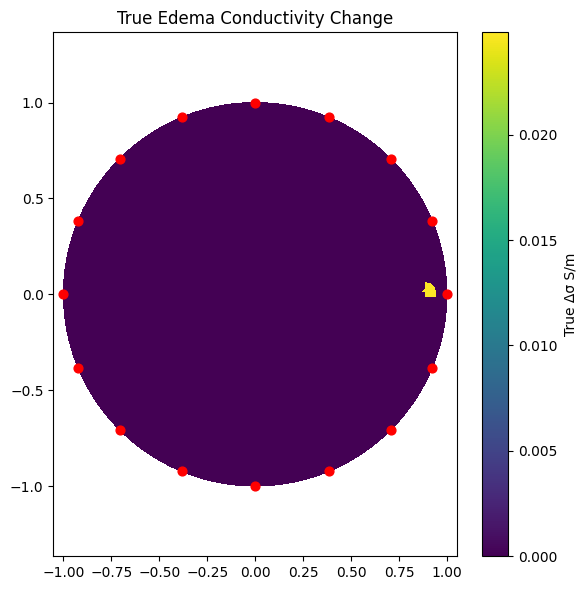

Saved: /notebooks/gitupload/results/pinn_fat_layer/figures/case_001_v2_true_delta_sigma.png


In [33]:
# ---------------------------------------------------------
# Plot true edema delta and PINN reconstructed delta
# ---------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.tripcolor(
    node_2d[:, 0],
    node_2d[:, 1],
    element,
    delta_sigma_true,
    shading="flat"
)
plt.colorbar(label="True Δσ S/m")
plt.scatter(node_2d[mesh_obj.el_pos, 0], node_2d[mesh_obj.el_pos, 1], c="red", s=40)
plt.title("True Edema Conductivity Change")
plt.axis("equal")
plt.tight_layout()

fig_path = FIG_DIR / f"{CASE_ID}_true_delta_sigma.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

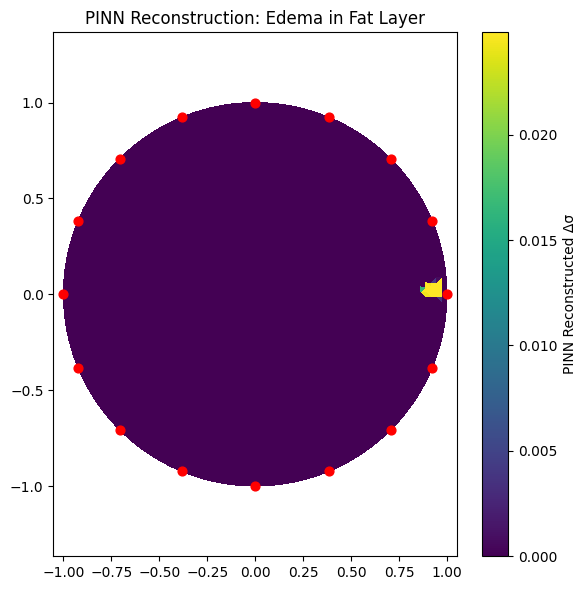

Saved: /notebooks/gitupload/results/pinn_fat_layer/figures/case_001_v2_pinn_reconstruction.png


In [34]:
plt.figure(figsize=(6, 6))
plt.tripcolor(
    node_2d[:, 0],
    node_2d[:, 1],
    element,
    pred_delta_sigma_np,
    shading="flat"
)
plt.colorbar(label="PINN Reconstructed Δσ")
plt.scatter(node_2d[mesh_obj.el_pos, 0], node_2d[mesh_obj.el_pos, 1], c="red", s=40)
plt.title("PINN Reconstruction: Edema in Fat Layer")
plt.axis("equal")
plt.tight_layout()

fig_path = FIG_DIR / f"{CASE_ID}_pinn_reconstruction.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

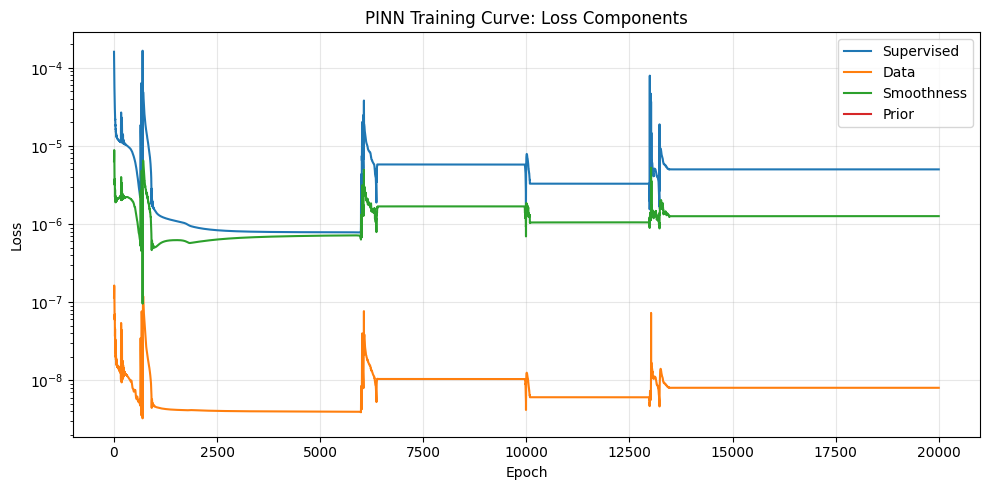

Saved: /notebooks/gitupload/results/pinn_fat_layer/figures/case_001_v2_pinn_loss_components.png


In [35]:
plt.figure(figsize=(10, 5))
plt.plot(history["epoch"], history["supervised_loss"], label="Supervised")
plt.plot(history["epoch"], history["data_loss"], label="Data")
plt.plot(history["epoch"], history["smoothness_loss"], label="Smoothness")
plt.plot(history["epoch"], history["prior_loss"], label="Prior")
plt.title("PINN Training Curve: Loss Components")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / f"{CASE_ID}_pinn_loss_components.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

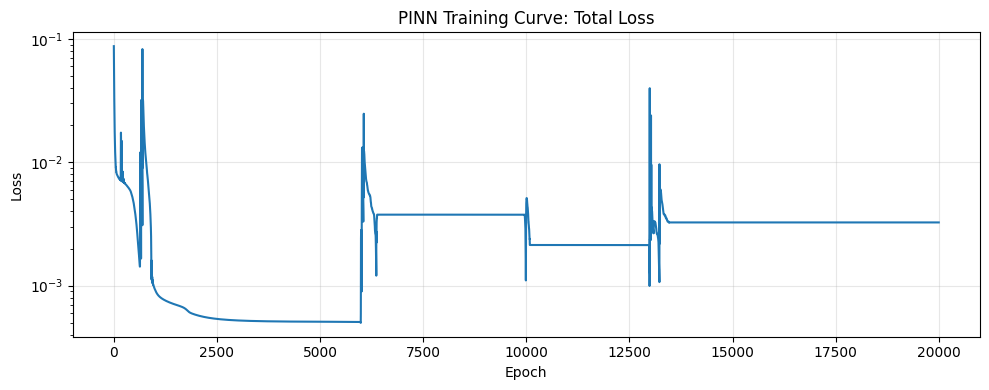

Saved: /notebooks/gitupload/results/pinn_fat_layer/figures/case_001_v2_pinn_total_loss.png


In [36]:
# ---------------------------------------------------------
# Plot training curves
# ---------------------------------------------------------

plt.figure(figsize=(10, 4))
plt.plot(history["epoch"], history["total_loss"])
plt.title("PINN Training Curve: Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIG_DIR / f"{CASE_ID}_pinn_total_loss.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)

In [37]:
# ---------------------------------------------------------
# Save training output
# ---------------------------------------------------------

np.savez(
    TRAIN_OUTPUT_FILE,
    pred_delta_sigma=pred_delta_sigma_np.astype(np.float32),
    dv_pred=final_dv_pred_np.astype(np.float32),
    delta_sigma_true=delta_sigma_true.astype(np.float32),
    edema_mask_true=edema_mask_np.astype(np.float32),
    fat_mask=fat_mask_np.astype(np.float32),
    X_input=X_input.astype(np.float32),
    J=J.astype(np.float32),
    dv=dv.astype(np.float32),
    edges=edges.astype(np.int32),
    epoch=np.array([best_checkpoint["epoch"]], dtype=np.int32),
    best_loss=np.array([best_checkpoint["best_loss"]], dtype=np.float32),
    final_supervised_loss=np.array([final_sup_loss.item()], dtype=np.float32),
    final_data_loss=np.array([final_data_loss.item()], dtype=np.float32),
    final_smoothness_loss=np.array([final_smooth_loss.item()], dtype=np.float32),
    final_prior_loss=np.array([final_prior_loss.item()], dtype=np.float32),
)

print("Saved training output to:", TRAIN_OUTPUT_FILE)

Saved training output to: /notebooks/gitupload/results/pinn_fat_layer/checkpoints/pinn_train_output_case_001_v2.npz


In [38]:
# ---------------------------------------------------------
# Run remaining 49 frequency-dependent cases
# Same PINN model and same loss style.
# Only voltage/data generation is now frequency-dependent.
# ---------------------------------------------------------
# IMPORTANT:
# 1. First check the output of case_001 from the cells above.
# 2. Then set RUN_REMAINING_49 = True and run this cell.
# ---------------------------------------------------------

# RUN_REMAINING_49 = False
RUN_REMAINING_49 = True


def run_frequency_case_with_same_pinn(case_config, plot_result=True):
    """
    Run one frequency-dependent case using:
    - same PINNMLP model
    - same loss functions
    - same training style
    - new 6-frequency voltage input
    """

    global CASE_ID, BEST_MODEL_FILE, LATEST_MODEL_FILE, TRAIN_HISTORY_FILE, TRAIN_OUTPUT_FILE
    global CURRENT_CASE, DELTA_SIGMA_MAX
    global mesh_healthy, mesh_edema, muscle_mask, fat_mask, edema_mask
    global V0_all, V1_all, dv_frequency_input, fd_healthy_blocks, fd_edema_blocks, dv_fd_blocks
    global v0, v1, delta_v, v1_noisy, dv
    global X_tensor, delta_sigma_true_tensor, sigma_true_tensor
    global delta_sigma_baseline_tensor, baseline_guidance_weight_tensor
    global J_tensor, dv_tensor, edges_tensor
    global fat_mask_tensor, edema_mask_tensor, non_edema_mask_tensor
    global recon_support_mask_tensor, outside_recon_mask_tensor
    global recon_support_mask_np, outside_recon_mask_np, r_norm
    global model, optimizer, history, best_loss, start_epoch
    global pred_delta_sigma_np, final_dv_pred_np

    CURRENT_CASE = case_config
    CASE_ID = case_config["case_id"]
    DELTA_SIGMA_MAX = case_config["delta_sigma_max"]

    print("\n" + "=" * 90)
    print("Running frequency-dependent case:", CASE_ID)
    print("Edema center:", case_config["edema_center"])
    print("Edema radius:", case_config["edema_radius"])
    print("Reference delta sigma:", DELTA_SIGMA_MAX)

    # -----------------------------------------------------
    # Reference-frequency mesh for true Δσ and plotting
    # -----------------------------------------------------
    mesh_healthy, mesh_edema, muscle_mask, fat_mask, edema_mask = create_layered_leg_with_edema(
        mesh_obj,
        edema_center=case_config["edema_center"],
        edema_radius=case_config["edema_radius"],
        sigma_fat=case_config["sigma_fat"],
        sigma_muscle=case_config["sigma_muscle"],
        sigma_edema=case_config["sigma_edema"],
        muscle_boundary=MUSCLE_BOUNDARY,
        verbose=False
    )

    # -----------------------------------------------------
    # Solve 6-frequency voltages
    # -----------------------------------------------------
    V0_all, V1_all, meshes_healthy_all, meshes_edema_all, masks_ref = solve_all_frequency_voltages(
        case_config,
        verbose=False
    )

    v0 = V0_all[REF_IDX]
    v1 = V1_all[REF_IDX]
    delta_v = v1 - v0

    dv_frequency_input, fd_healthy_blocks, fd_edema_blocks, dv_fd_blocks, alpha_values = \
        build_weighted_frequency_difference_input(
            V0_all,
            V1_all,
            ref_idx=REF_IDX,
            snr_db=snr_db,
            verbose=False
        )

    # Keep old variable name alive.
    v1_noisy = v0 + add_noise(delta_v, snr_db=snr_db)

    # -----------------------------------------------------
    # Dataset preparation
    # -----------------------------------------------------
    node_2d = mesh_obj.node[:, :2]
    element = mesh_obj.element
    n_elements = element.shape[0]

    region_coords_raw = np.mean(node_2d[element], axis=1).astype(np.float32)

    x = region_coords_raw[:, 0]
    y = region_coords_raw[:, 1]

    r_node = np.sqrt(node_2d[:, 0]**2 + node_2d[:, 1]**2)
    r_max = np.max(r_node)

    x_norm = x / r_max
    y_norm = y / r_max

    # Neural input remains only x and y.
    X_input = np.stack([x_norm, y_norm], axis=1).astype(np.float32)

    delta_sigma_true = (mesh_edema.perm - mesh_healthy.perm).astype(np.float32)
    sigma_true = mesh_edema.perm.astype(np.float32)

    dv = dv_frequency_input.astype(np.float32)

    fat_mask_np = np.asarray(fat_mask).astype(bool)
    edema_mask_np = np.asarray(edema_mask).astype(bool)

    # -----------------------------------------------------
    # Reconstruction support mask
    # Forward model still uses full fat layer.
    # PINN reconstruction is allowed only inside this support region.
    # -----------------------------------------------------
    r_norm = np.sqrt(x_norm**2 + y_norm**2)

    recon_support_mask_np = (
        (r_norm > MUSCLE_BOUNDARY + RECON_INNER_CLEARANCE) &
        (r_norm < 1.0 - RECON_OUTER_CLEARANCE)
    )

    outside_recon_mask_np = ~recon_support_mask_np

    edema_outside_support = np.sum(edema_mask_np & outside_recon_mask_np)
    if edema_outside_support > 0:
        print("Warning: true edema outside reconstruction support:", edema_outside_support)
        print("Reduce RECON_OUTER_CLEARANCE or regenerate edema further inward.")

    # -----------------------------------------------------
    # Reference Jacobian and stacked frequency Jacobian
    # -----------------------------------------------------
    if USE_HEALTHY_10KHZ_JACOBIAN:
        mesh_inverse = copy.deepcopy(mesh_healthy)
        mesh_inverse.perm = mesh_healthy.perm.astype(np.float32)
    else:
        mesh_inverse = copy.deepcopy(mesh_obj)
        mesh_inverse.perm = np.ones(n_elements, dtype=np.float32)

    eit_pinn = jac.JAC(mesh_inverse, protocol_obj)
    eit_pinn.setup(
        p=0.5,
        lamb=0.01,
        method="kotre"
    )

    J_ref = extract_jacobian(eit_pinn).astype(np.float32)

    one_freq_measurements = V0_all.shape[1]

    if J_ref.shape[0] != one_freq_measurements and J_ref.shape[1] == one_freq_measurements:
        J_ref = J_ref.T

    if J_ref.shape[0] != one_freq_measurements:
        raise ValueError(f"J_ref rows {J_ref.shape[0]} must match {one_freq_measurements}")

    if J_ref.shape[1] != n_elements:
        raise ValueError(f"J_ref columns {J_ref.shape[1]} must match mesh elements {n_elements}")

    J, contrast_scales = build_stacked_frequency_jacobian(
        J_ref,
        case_config,
        ref_idx=REF_IDX
    )

    if J.shape[0] != dv.shape[0]:
        raise ValueError(f"J rows {J.shape[0]} must match dv rows {dv.shape[0]}")

    # -----------------------------------------------------
    # Edges
    # -----------------------------------------------------
    edges = build_element_edges(element)

    # -----------------------------------------------------
    # Baseline guidance disabled, same as previous code
    # -----------------------------------------------------
    delta_sigma_baseline = np.zeros(n_elements, dtype=np.float32)
    baseline_guidance_weight = np.zeros(n_elements, dtype=np.float32)

    # -----------------------------------------------------
    # Tensors
    # -----------------------------------------------------
    X_tensor = to_tensor(X_input)

    delta_sigma_true_tensor = to_tensor(delta_sigma_true).view(-1, 1)
    sigma_true_tensor = to_tensor(sigma_true).view(-1, 1)

    delta_sigma_baseline_tensor = to_tensor(delta_sigma_baseline).view(-1, 1)
    baseline_guidance_weight_tensor = to_tensor(baseline_guidance_weight).view(-1, 1)

    J_tensor = to_tensor(J)
    dv_tensor = to_tensor(dv).view(-1, 1)

    edges_tensor = torch.tensor(edges, dtype=torch.long, device=device)

    fat_mask_tensor = to_tensor(fat_mask_np.astype(np.float32)).view(-1, 1)
    edema_mask_tensor = to_tensor(edema_mask_np.astype(np.float32)).view(-1, 1)
    non_edema_mask_tensor = 1.0 - edema_mask_tensor

    recon_support_mask_tensor = to_tensor(
        recon_support_mask_np.astype(np.float32)
    ).view(-1, 1)

    outside_recon_mask_tensor = 1.0 - recon_support_mask_tensor

    # -----------------------------------------------------
    # New model per case, same PINN architecture
    # -----------------------------------------------------
    model = PINNMLP(
        in_dim=2,
        hidden_dim=128,
        num_hidden_layers=4,
        out_dim=1
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=LR)

    # -----------------------------------------------------
    # Training history
    # -----------------------------------------------------
    history = {
        "epoch": [],
        "total_loss": [],
        "supervised_loss": [],
        "data_loss": [],
        "smoothness_loss": [],
        "prior_loss": [],
        "background_loss": [],
        "sparse_loss": [],
    }

    best_loss = float("inf")
    start_epoch = 1

    BEST_MODEL_FILE = CHECKPOINT_DIR / f"best_pinn_{CASE_ID}.pt"
    LATEST_MODEL_FILE = CHECKPOINT_DIR / f"latest_pinn_{CASE_ID}.pt"
    TRAIN_HISTORY_FILE = LOG_DIR / f"train_history_{CASE_ID}.json"
    TRAIN_OUTPUT_FILE = CHECKPOINT_DIR / f"pinn_train_output_{CASE_ID}.npz"

    # -----------------------------------------------------
    # Train PINN
    # -----------------------------------------------------
    start_time = time.time()

    for epoch in range(start_epoch, EPOCHS + 1):
        model.train()
        optimizer.zero_grad()

        raw_pred_delta_sigma = model(X_tensor)

        pred_delta_sigma = DELTA_SIGMA_MAX * torch.sigmoid(raw_pred_delta_sigma)

        # Restrict reconstruction away from outer boundary
        pred_delta_sigma = pred_delta_sigma * recon_support_mask_tensor

        l_sup = supervised_loss(pred_delta_sigma, delta_sigma_true_tensor)
        l_data, dv_pred = measurement_loss(pred_delta_sigma, J_tensor, dv_tensor)
        l_smooth = smoothness_loss(pred_delta_sigma, edges_tensor)
        l_prior = prior_guidance_loss(
            pred_delta_sigma,
            delta_sigma_baseline_tensor,
            baseline_guidance_weight_tensor
        )

        l_bg = background_zero_loss(pred_delta_sigma)
        l_sparse = sparsity_loss(pred_delta_sigma)

        total_loss = (
            LAMBDA_SUP * l_sup +
            LAMBDA_DATA * l_data +
            LAMBDA_SMOOTH * l_smooth +
            LAMBDA_PRIOR * l_prior +
            LAMBDA_BG * l_bg +
            LAMBDA_SPARSE * l_sparse
        )

        total_loss.backward()
        optimizer.step()

        history["epoch"].append(epoch)
        history["total_loss"].append(float(total_loss.item()))
        history["supervised_loss"].append(float(l_sup.item()))
        history["data_loss"].append(float(l_data.item()))
        history["smoothness_loss"].append(float(l_smooth.item()))
        history["prior_loss"].append(float(l_prior.item()))
        history["background_loss"].append(float(l_bg.item()))
        history["sparse_loss"].append(float(l_sparse.item()))

        if total_loss.item() < best_loss:
            best_loss = float(total_loss.item())
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_loss": best_loss,
                "history": history
            }, BEST_MODEL_FILE)

        if epoch % SAVE_EVERY == 0 or epoch == EPOCHS:
            torch.save({
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_loss": best_loss,
                "history": history
            }, LATEST_MODEL_FILE)

            save_json(TRAIN_HISTORY_FILE, history)

        if epoch % PRINT_EVERY == 0 or epoch == 1 or epoch == EPOCHS:
            print(
                f"{CASE_ID} | Epoch {epoch:5d}/{EPOCHS} | "
                f"total={total_loss.item():.6e} | "
                f"sup={l_sup.item():.6e} | "
                f"data={l_data.item():.6e} | "
                f"smooth={l_smooth.item():.6e} | "
                f"bg={l_bg.item():.6e} | "
                f"sparse={l_sparse.item():.6e} | "
                f"pred_max={pred_delta_sigma.max().item():.6e}"
            )

    elapsed = time.time() - start_time
    print(f"{CASE_ID} training completed in {elapsed:.2f} seconds.")

    # -----------------------------------------------------
    # Load best model and evaluate
    # -----------------------------------------------------
    best_checkpoint = torch.load(BEST_MODEL_FILE, map_location=device)
    model.load_state_dict(best_checkpoint["model_state"])
    model.eval()

    with torch.no_grad():
        raw_pred_delta_sigma = model(X_tensor)
        pred_delta_sigma = DELTA_SIGMA_MAX * torch.sigmoid(raw_pred_delta_sigma)
        pred_delta_sigma = pred_delta_sigma * recon_support_mask_tensor

        final_sup_loss = supervised_loss(pred_delta_sigma, delta_sigma_true_tensor)
        final_data_loss, final_dv_pred = measurement_loss(pred_delta_sigma, J_tensor, dv_tensor)
        final_smooth_loss = smoothness_loss(pred_delta_sigma, edges_tensor)
        final_bg_loss = background_zero_loss(pred_delta_sigma)
        final_sparse_loss = sparsity_loss(pred_delta_sigma)
        final_prior_loss = prior_guidance_loss(
            pred_delta_sigma,
            delta_sigma_baseline_tensor,
            baseline_guidance_weight_tensor
        )

    pred_delta_sigma_np = pred_delta_sigma.detach().cpu().numpy().reshape(-1)
    final_dv_pred_np = final_dv_pred.detach().cpu().numpy().reshape(-1)

    # -----------------------------------------------------
    # Save figures
    # -----------------------------------------------------
    if plot_result:
        plt.figure(figsize=(6, 6))
        plt.tripcolor(
            node_2d[:, 0],
            node_2d[:, 1],
            element,
            delta_sigma_true,
            shading="flat"
        )
        plt.colorbar(label="True Δσ at 10 kHz S/m")
        plt.scatter(node_2d[mesh_obj.el_pos, 0], node_2d[mesh_obj.el_pos, 1], c="red", s=40)
        plt.title(f"{CASE_ID}: True Edema Δσ at 10 kHz")
        plt.axis("equal")
        plt.tight_layout()
        fig_path = FIG_DIR / f"{CASE_ID}_true_delta_sigma_10khz.png"
        plt.savefig(fig_path, dpi=200, bbox_inches="tight")
        plt.close()

        plt.figure(figsize=(6, 6))
        plt.tripcolor(
            node_2d[:, 0],
            node_2d[:, 1],
            element,
            pred_delta_sigma_np,
            shading="flat"
        )
        plt.colorbar(label="PINN Reconstructed Δσ")
        plt.scatter(node_2d[mesh_obj.el_pos, 0], node_2d[mesh_obj.el_pos, 1], c="red", s=40)
        plt.title(f"{CASE_ID}: Frequency-Dependent PINN Reconstruction")
        plt.axis("equal")
        plt.tight_layout()
        fig_path = FIG_DIR / f"{CASE_ID}_fd_pinn_reconstruction.png"
        plt.savefig(fig_path, dpi=200, bbox_inches="tight")
        plt.close()

        plt.figure(figsize=(10, 4))
        plt.plot(history["epoch"], history["total_loss"])
        plt.title(f"{CASE_ID}: PINN Training Curve")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.yscale("log")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        fig_path = FIG_DIR / f"{CASE_ID}_pinn_total_loss.png"
        plt.savefig(fig_path, dpi=200, bbox_inches="tight")
        plt.close()

    # -----------------------------------------------------
    # Save output
    # -----------------------------------------------------
    np.savez(
        TRAIN_OUTPUT_FILE,
        pred_delta_sigma=pred_delta_sigma_np.astype(np.float32),
        dv_pred=final_dv_pred_np.astype(np.float32),
        delta_sigma_true=delta_sigma_true.astype(np.float32),
        edema_mask_true=edema_mask_np.astype(np.float32),
        fat_mask=fat_mask_np.astype(np.float32),
        recon_support_mask=recon_support_mask_np.astype(np.float32),
        outside_recon_mask=outside_recon_mask_np.astype(np.float32),
        X_input=X_input.astype(np.float32),
        J=J.astype(np.float32),
        J_ref=J_ref.astype(np.float32),
        dv=dv.astype(np.float32),
        dv_frequency_input=dv_frequency_input.astype(np.float32),
        V0_all=V0_all.astype(np.float32),
        V1_all=V1_all.astype(np.float32),
        fd_healthy_blocks=fd_healthy_blocks.astype(np.float32),
        fd_edema_blocks=fd_edema_blocks.astype(np.float32),
        dv_fd_blocks=dv_fd_blocks.astype(np.float32),
        alpha_values=alpha_values.astype(np.float32),
        contrast_scales=contrast_scales.astype(np.float32),
        freqs_khz=FREQS_KHZ.astype(np.float32),
        edges=edges.astype(np.int32),
        epoch=np.array([best_checkpoint["epoch"]], dtype=np.int32),
        best_loss=np.array([best_checkpoint["best_loss"]], dtype=np.float32),
        final_supervised_loss=np.array([final_sup_loss.item()], dtype=np.float32),
        final_data_loss=np.array([final_data_loss.item()], dtype=np.float32),
        final_smoothness_loss=np.array([final_smooth_loss.item()], dtype=np.float32),
        final_prior_loss=np.array([final_prior_loss.item()], dtype=np.float32),
    )

    case_result = {
        "case_id": CASE_ID,
        "edema_center_x": case_config["edema_center"][0],
        "edema_center_y": case_config["edema_center"][1],
        "edema_radius": case_config["edema_radius"],
        "sigma_fat_10khz": case_config["sigma_fat"],
        "sigma_muscle_10khz": case_config["sigma_muscle"],
        "sigma_edema_10khz": case_config["sigma_edema"],
        "delta_sigma_10khz": case_config["delta_sigma_max"],
        "edema_elements": int(edema_mask_np.sum()),
        "dv_shape": str(dv.shape),
        "J_shape": str(J.shape),
        "best_epoch": int(best_checkpoint["epoch"]),
        "best_loss": float(best_checkpoint["best_loss"]),
        "final_supervised_loss": float(final_sup_loss.item()),
        "final_data_loss": float(final_data_loss.item()),
        "final_smoothness_loss": float(final_smooth_loss.item()),
        "pred_delta_min": float(pred_delta_sigma_np.min()),
        "pred_delta_max": float(pred_delta_sigma_np.max()),
        "pred_delta_mean": float(pred_delta_sigma_np.mean())
    }

    return case_result


if not RUN_REMAINING_49:
    print("Remaining 49 cases not started.")
    print("First check case_001 output.")
    print("Then change:")
    print("    RUN_REMAINING_49 = False")
    print("to:")
    print("    RUN_REMAINING_49 = True")
else:
    all_results = []

    # Save metadata for all generated cases.
    case_table = pd.DataFrame(CASE_LIST)
    case_table.to_csv(PINN_DIR / "generated_50_frequency_case_metadata.csv", index=False)

    for case_config in CASE_LIST[1:]:
        result = run_frequency_case_with_same_pinn(case_config, plot_result=True)
        all_results.append(result)

    results_df = pd.DataFrame(all_results)
    results_df.to_csv(PINN_DIR / "remaining_49_frequency_case_results.csv", index=False)

    print("Completed remaining 49 frequency-dependent cases.")
    print("Saved result summary:", PINN_DIR / "remaining_49_frequency_case_results.csv")
    display(results_df)



Running frequency-dependent case: case_002_v2
Edema center: (0.898526132106781, 0.10721287876367569)
Edema radius: 0.04056197036348872
Reference delta sigma: 0.01824156753718853
case_002_v2 | Epoch     1/20000 | total=5.151836e-02 | sup=9.569830e-05 | data=5.879957e-08 | smooth=3.350332e-06 | bg=2.440718e-05 | sparse=2.690416e-03 | pred_max=9.288871e-03
case_002_v2 | Epoch  1000/20000 | total=4.488984e-04 | sup=7.081322e-07 | data=1.689875e-09 | smooth=2.993003e-07 | bg=6.307322e-07 | sparse=7.360114e-05 | pred_max=1.824107e-02
case_002_v2 | Epoch  2000/20000 | total=2.911811e-04 | sup=4.508796e-07 | data=1.439347e-09 | smooth=3.401613e-07 | bg=4.370951e-07 | sparse=5.853374e-05 | pred_max=1.824157e-02
case_002_v2 | Epoch  3000/20000 | total=2.764267e-04 | sup=4.255487e-07 | data=1.405258e-09 | smooth=3.725581e-07 | bg=4.232108e-07 | sparse=5.644466e-05 | pred_max=1.824157e-02
case_002_v2 | Epoch  4000/20000 | total=2.747163e-04 | sup=4.225577e-07 | data=1.397327e-09 | smooth=3.827288

,case_id,edema_center_x,edema_center_y,edema_radius,sigma_fat_10khz,sigma_muscle_10khz,sigma_edema_10khz,delta_sigma_10khz,edema_elements,dv_shape,J_shape,best_epoch,best_loss,final_supervised_loss,final_data_loss,final_smoothness_loss,pred_delta_min,pred_delta_max,pred_delta_mean
0,case_002_v2,0.898526,0.107213,0.040562,0.024022,0.360330,0.042264,0.018242,14,"(1040,)","(1040, 7901)",19314,2.739187e-04,4.211555e-07,1.388112e-09,3.964358e-07,0.0,0.018242,0.000055
1,case_003_v2,0.878560,0.193085,0.043319,0.023487,0.362831,0.045143,0.021656,15,"(1040,)","(1040, 7901)",4146,5.067032e-04,8.044356e-07,2.628665e-09,5.747829e-07,0.0,0.021656,0.000077
2,case_004_v2,0.843382,0.315475,0.037920,0.024326,0.349805,0.048017,0.023691,12,"(1040,)","(1040, 7901)",8574,5.061530e-04,7.862192e-07,1.044039e-08,7.293174e-07,0.0,0.023691,0.000071
3,case_005_v2,0.774882,0.456735,0.039887,0.020747,0.317264,0.047332,0.026585,12,"(1040,)","(1040, 7901)",4409,6.969491e-04,1.078046e-06,2.556857e-09,1.133951e-06,0.0,0.026585,0.000081
4,case_006_v2,0.732580,0.527936,0.038404,0.022691,0.319663,0.042280,0.019589,13,"(1040,)","(1040, 7901)",13147,2.660670e-04,4.844539e-07,1.287508e-09,5.453109e-07,0.0,0.019589,0.000057
5,case_007_v2,0.670067,0.599152,0.040812,0.022543,0.363507,0.047489,0.024946,14,"(1040,)","(1040, 7901)",9160,5.994478e-04,4.958212e-05,1.046651e-08,7.902594e-07,0.0,0.024946,0.000073
6,case_008_v2,0.616445,0.656592,0.044973,0.023663,0.316273,0.042920,0.019256,16,"(1040,)","(1040, 7901)",5365,3.634211e-04,5.626497e-07,1.128358e-08,5.063615e-07,0.0,0.019256,0.000068
7,case_009_v2,0.518610,0.739582,0.036718,0.024112,0.338029,0.046288,0.022176,13,"(1040,)","(1040, 7901)",13734,3.234788e-04,4.493636e-06,1.229588e-09,4.681356e-07,0.0,0.022176,0.000055
8,case_010_v2,0.370206,0.820955,0.043304,0.022698,0.345277,0.048080,0.025382,14,"(1040,)","(1040, 7901)",19972,4.242316e-04,6.523159e-07,1.432902e-08,7.675746e-07,0.0,0.025382,0.000071
9,case_011_v2,0.310293,0.848092,0.041128,0.021935,0.308848,0.045082,0.023147,15,"(1040,)","(1040, 7901)",19840,4.851120e-04,7.459508e-07,1.552033e-08,6.384525e-07,0.0,0.023147,0.000076
